In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

In [ ]:
#load files

df = pd.read_excel("BEV Registrations.xlsx")

df.head()

df_2 = pd.read_excel("BEV Registrations Norway.xlsx")
df_2.head()


,Año,Mes,BEV registrations
0,2014,1,1078
1,2014,2,1333
2,2014,3,2696
3,2014,4,1218
4,2014,5,1290


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Año                144 non-null    int64
 1   Mes                144 non-null    int64
 2   BEV registrations  144 non-null    int64
dtypes: int64(3)
memory usage: 3.5 KB


In [6]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Año                144 non-null    int64
 1   Mes                144 non-null    int64
 2   BEV registrations  144 non-null    int64
dtypes: int64(3)
memory usage: 3.5 KB


In [ ]:
# statistics summary

summary_stats = df.describe().T[
    ["mean", "std", "min", "max"]
]

summary_stats


,mean,std,min,max
Año,2019.500000,3.464102,2014.0,2025.0
Mes,6.500000,3.464102,1.0,12.0
BEV registrations,2766.444444,3106.812458,33.0,15304.0


In [ ]:
df["date"] = pd.to_datetime(
    df["Año"].astype(str) + "-" + df["Mes"].astype(str).str.zfill(2)
)
df = df.sort_values("date").reset_index(drop=True)

df.head()

df_2["date"] = pd.to_datetime(
    df_2["Año"].astype(str) + "-" + df_2["Mes"].astype(str).str.zfill(2)
)

df_2 = df_2.sort_values("date").reset_index(drop=True)

df_2.head()


,Año,Mes,BEV registrations,date
0,2014,1,1078,2014-01-01
1,2014,2,1333,2014-02-01
2,2014,3,2696,2014-03-01
3,2014,4,1218,2014-04-01
4,2014,5,1290,2014-05-01


In [ ]:
df.columns = [c.strip() for c in df.columns]


col_year = next((c for c in df.columns if c.lower() in ["año", "ano", "year"]), None)
col_month = next((c for c in df.columns if c.lower() in ["mes", "month"]), None)
col_val = next((c for c in df.columns if "bev" in c.lower()), None)

if not (col_year and col_month and col_val):
    raise ValueError(f"Could not auto-detect columns. Found: {df.columns.tolist()}")

df = df.rename(columns={col_year: "year", col_month: "month", col_val: "bev"})
df.head()

### Norway

df_2.columns = [c.strip() for c in df_2.columns]

col_year = next((c for c in df_2.columns if c.lower() in ["año", "ano", "year"]), None)
col_month = next((c for c in df_2.columns if c.lower() in ["mes", "month"]), None)
col_val = next((c for c in df_2.columns if "bev" in c.lower()), None)

if not (col_year and col_month and col_val):
    raise ValueError(f"Could not auto-detect columns. Found: {df_2.columns.tolist()}")

df_2 = df_2.rename(columns={col_year: "year", col_month: "month", col_val: "bev"})
df_2.head()

,year,month,bev,date
0,2014,1,1078,2014-01-01
1,2014,2,1333,2014-02-01
2,2014,3,2696,2014-03-01
3,2014,4,1218,2014-04-01
4,2014,5,1290,2014-05-01


In [ ]:
df["date"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" + df["month"].astype(int).astype(str).str.zfill(2))
df = df.sort_values("date").reset_index(drop=True)

ts = df.set_index("date")["bev"].asfreq("MS")  # monthly start frequency
ts.head(), ts.tail()

### Norway

df_2["date"] = pd.to_datetime(df_2["year"].astype(int).astype(str) + "-" + df_2["month"].astype(int).astype(str).str.zfill(2))
df_2 = df_2.sort_values("date").reset_index(drop=True)

ts_2 = df_2.set_index("date")["bev"].asfreq("MS")  # monthly start frequency
ts_2.head(), ts_2.tail()



(date
 2014-01-01    1078
 2014-02-01    1333
 2014-03-01    2696
 2014-04-01    1218
 2014-05-01    1290
 Freq: MS, Name: bev, dtype: int64,
 date
 2025-08-01    13482
 2025-09-01    14084
 2025-10-01    10852
 2025-11-01    19427
 2025-12-01    34346
 Freq: MS, Name: bev, dtype: int64)

### Time Series Plots

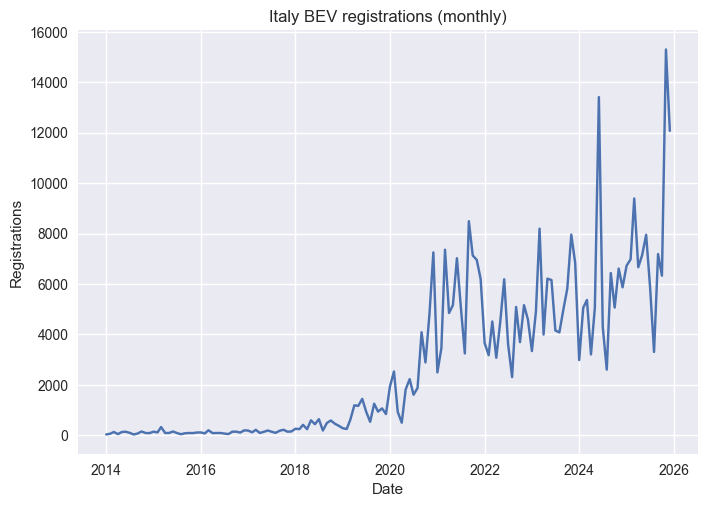

In [11]:
plt.figure()
plt.plot(ts.index, ts.values)
plt.title("Italy BEV registrations (monthly)")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.show()


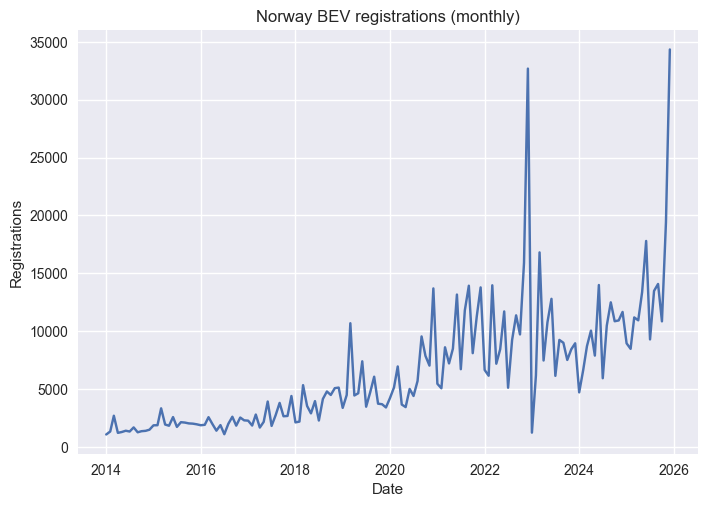

In [12]:
plt.figure()
plt.plot(ts_2.index, ts_2.values)
plt.title("Norway BEV registrations (monthly)")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.show()


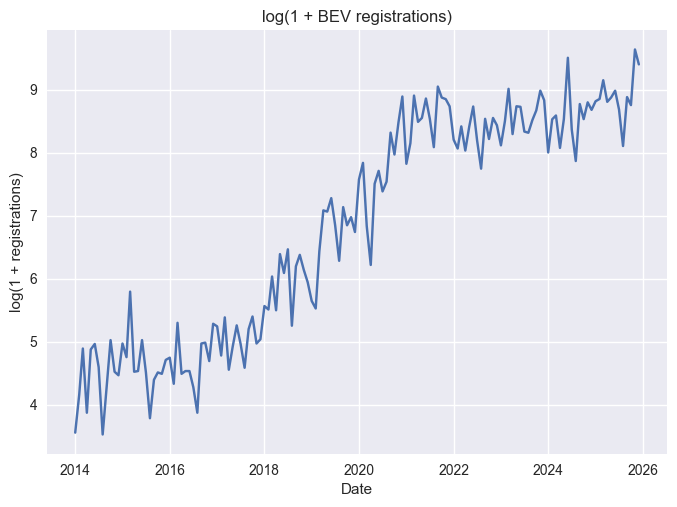

In [ ]:
ts_log = np.log1p(ts)

plt.figure()
plt.plot(ts_log.index, ts_log.values)
plt.title("log(1 + BEV registrations)")
plt.xlabel("Date")
plt.ylabel("log(1 + registrations)")
plt.show()


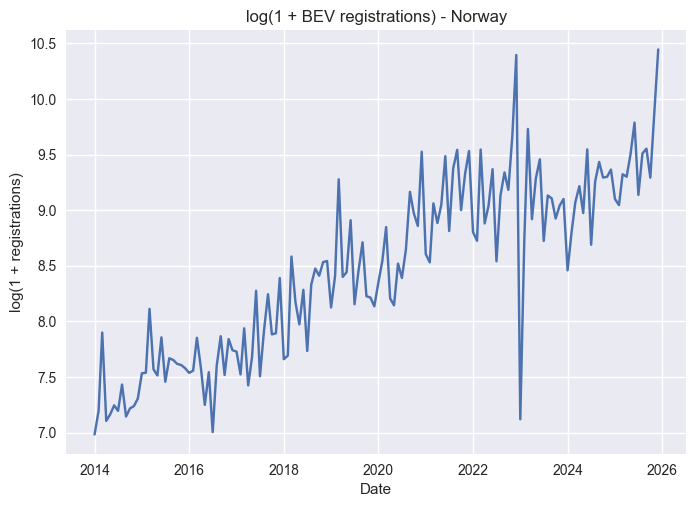

In [ ]:
#Norway

ts_log_2 = np.log1p(ts_2)

plt.figure()
plt.plot(ts_log_2.index, ts_log_2.values)
plt.title("log(1 + BEV registrations) - Norway")
plt.xlabel("Date")
plt.ylabel("log(1 + registrations)")
plt.show()

<Figure size 800x550 with 0 Axes>

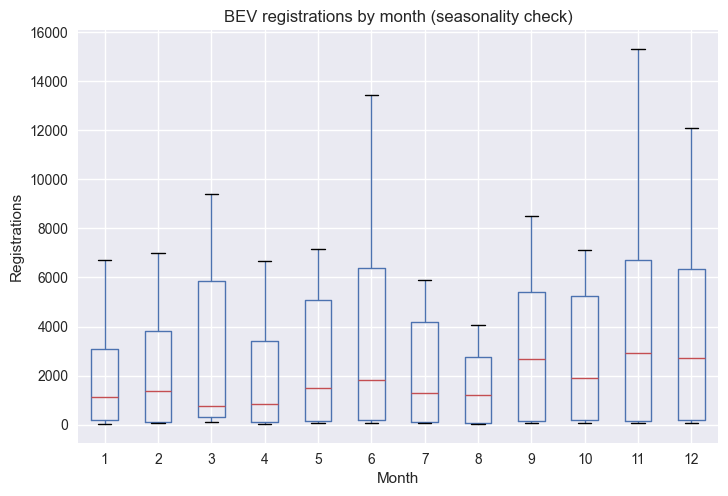

In [15]:
tmp = ts.to_frame("bev").copy()
tmp["month"] = tmp.index.month

plt.figure()
tmp.boxplot(column="bev", by="month")
plt.title("BEV registrations by month (seasonality check)")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Registrations")
plt.show()


<Figure size 800x550 with 0 Axes>

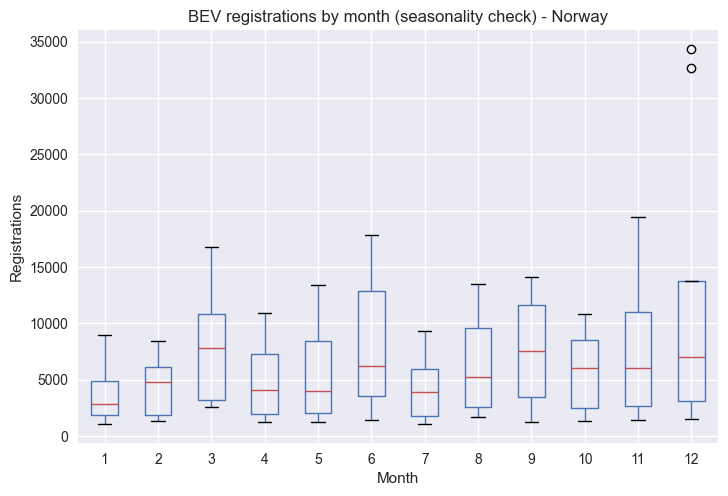

In [16]:
tmp_2 = ts_2.to_frame("bev").copy()
tmp_2["month"] = tmp_2.index.month

plt.figure()
tmp_2.boxplot(column="bev", by="month")
plt.title("BEV registrations by month (seasonality check) - Norway")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Registrations")
plt.show()


### Seasonal decomposition (trend/seasonal/resid)

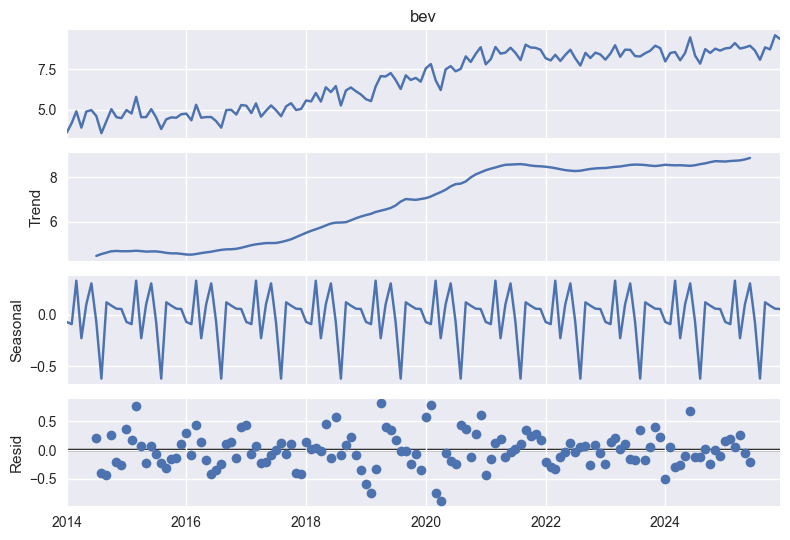

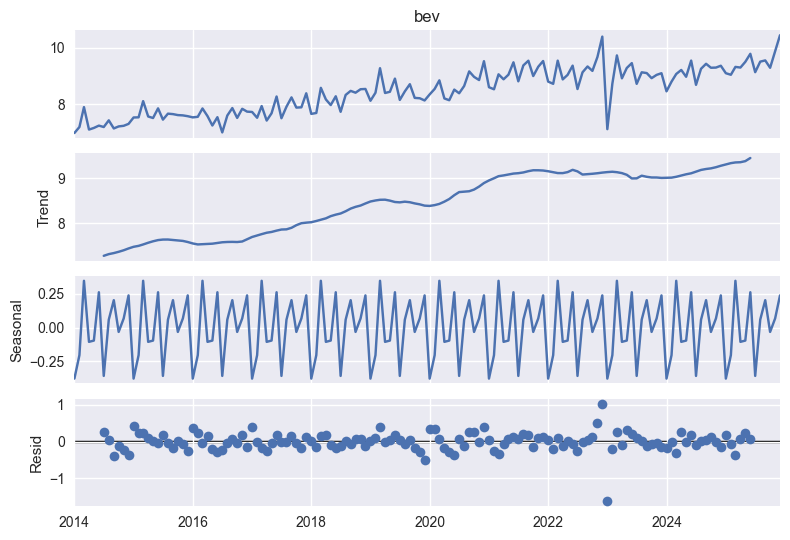

In [17]:
decomp = seasonal_decompose(ts_log, model="additive", period=12)

decomp.plot()
plt.show()

decomp_2 = seasonal_decompose(ts_log_2, model="additive", period=12)
decomp_2.plot()
plt.show()

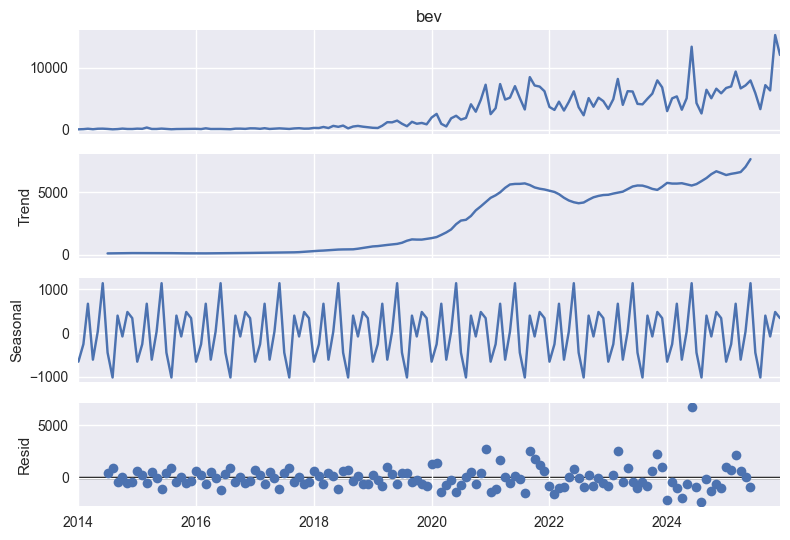

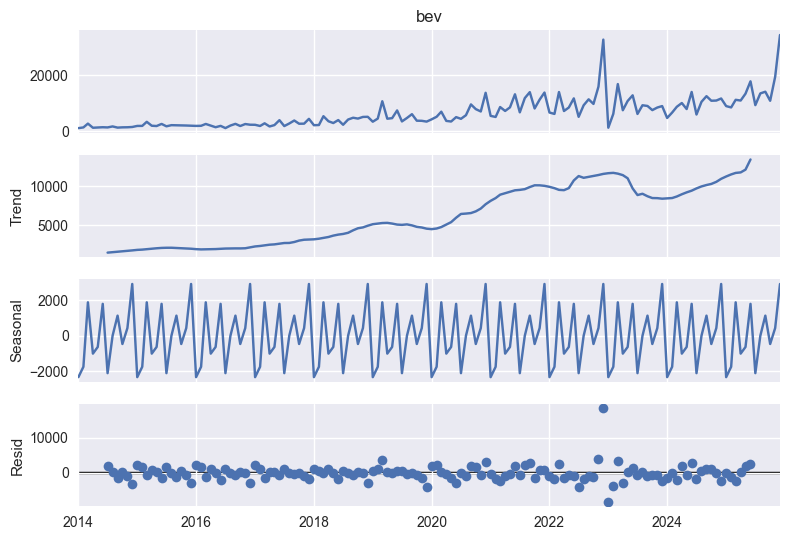

In [18]:
decomp_lvl = seasonal_decompose(ts, model="additive", period=12)
decomp_lvl.plot()
plt.show()

##Norway
decomp_lvl_2 = seasonal_decompose(ts_2, model="additive", period=12)
decomp_lvl_2.plot()
plt.show()

### Stationarity tests (ADF + KPSS)

In [19]:
def adf_test(x, name="series"):
    x = x.dropna()
    stat, p, lags, nobs, *_ = adfuller(x, autolag="AIC")
    print(f"ADF ({name}) -> stat={stat:.4f}, p={p:.4g}, lags={lags}, n={nobs}")

def kpss_test(x, name="series", regression="c"):
    x = x.dropna()
    stat, p, lags, crit = kpss(x, regression=regression, nlags="auto")
    print(f"KPSS ({name}) -> stat={stat:.4f}, p={p:.4g}, lags={lags}")

adf_test(ts, "BEV levels")
kpss_test(ts, "BEV levels", regression="c")

adf_test(ts_log, "log1p(BEV)")
kpss_test(ts_log, "log1p(BEV)", regression="c")

adf_test(ts_2, "BEV levels - Norway")
kpss_test(ts_2, "BEV levels - Norway", regression="c")

adf_test(ts_log_2, "log1p(BEV) - Norway")
kpss_test(ts_log_2, "log1p(BEV) - Norway", regression="c")


ADF (BEV levels) -> stat=0.1041, p=0.9663, lags=13, n=130
KPSS (BEV levels) -> stat=1.5662, p=0.01, lags=8
ADF (log1p(BEV)) -> stat=-0.5838, p=0.8746, lags=12, n=131
KPSS (log1p(BEV)) -> stat=1.6317, p=0.01, lags=8
ADF (BEV levels - Norway) -> stat=0.5584, p=0.9865, lags=5, n=138
KPSS (BEV levels - Norway) -> stat=1.5729, p=0.01, lags=8
ADF (log1p(BEV) - Norway) -> stat=-0.5894, p=0.8734, lags=12, n=131
KPSS (log1p(BEV) - Norway) -> stat=1.6456, p=0.01, lags=8


In [20]:
ts_log_diff1 = ts_log.diff(1)
ts_log_diff12 = ts_log.diff(12)
ts_log_diff1_12 = ts_log.diff(1).diff(12)

adf_test(ts_log_diff1, "log1p diff(1)")
adf_test(ts_log_diff12, "log1p diff(12)")
adf_test(ts_log_diff1_12, "log1p diff(1)+diff(12)")

#Norway

ts_log_diff1_Nor = ts_log_2.diff(1)
ts_log_diff12_Nor = ts_log_2.diff(12)
ts_log_diff1_12_Nor = ts_log_2.diff(1).diff(12)

adf_test(ts_log_diff1_Nor, "log1p diff(1) - Norway")
adf_test(ts_log_diff12_Nor, "log1p diff(12) - Norway")
adf_test(ts_log_diff1_12_Nor, "log1p diff(1)+diff(12) - Norway")

ADF (log1p diff(1)) -> stat=-3.5645, p=0.006476, lags=11, n=131
ADF (log1p diff(12)) -> stat=-2.1091, p=0.2409, lags=12, n=119
ADF (log1p diff(1)+diff(12)) -> stat=-4.1558, p=0.0007822, lags=11, n=119
ADF (log1p diff(1) - Norway) -> stat=-4.0628, p=0.001115, lags=11, n=131
ADF (log1p diff(12) - Norway) -> stat=-4.2674, p=0.0005057, lags=11, n=120
ADF (log1p diff(1)+diff(12) - Norway) -> stat=-4.1154, p=0.0009133, lags=13, n=117


### Autocorrelation diagnostics (ACF/PACF)

<Figure size 800x550 with 0 Axes>

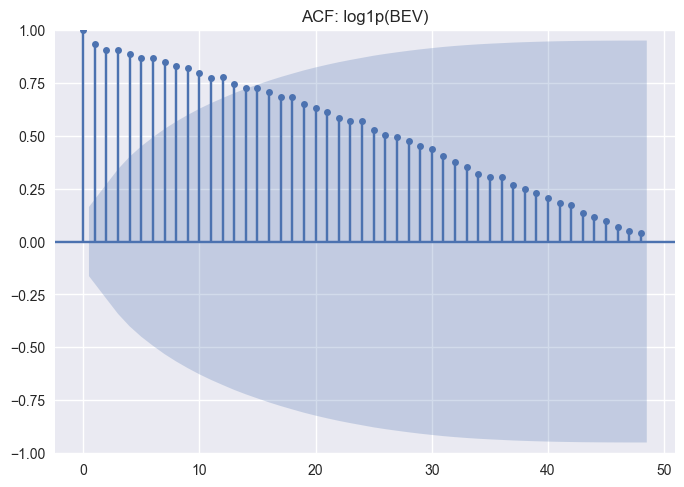

<Figure size 800x550 with 0 Axes>

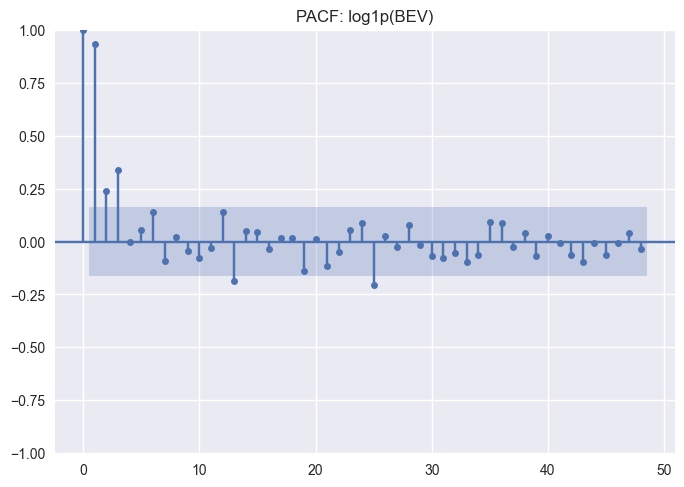

<Figure size 800x550 with 0 Axes>

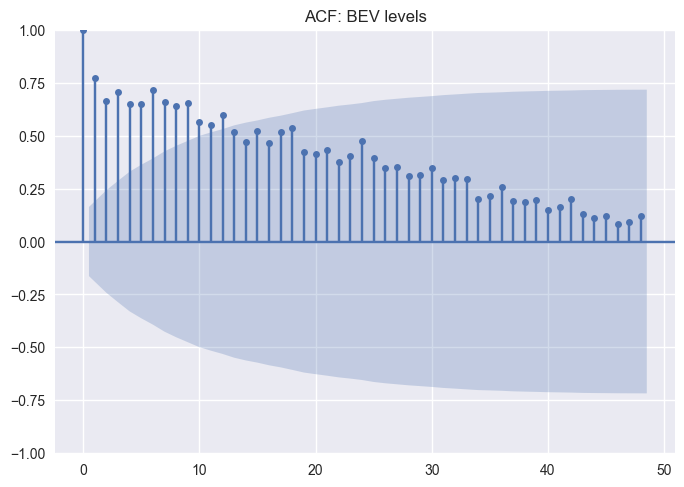

<Figure size 800x550 with 0 Axes>

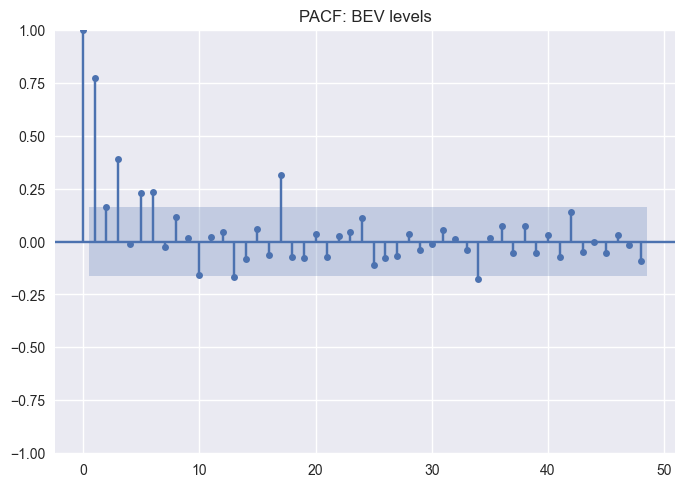

<Figure size 800x550 with 0 Axes>

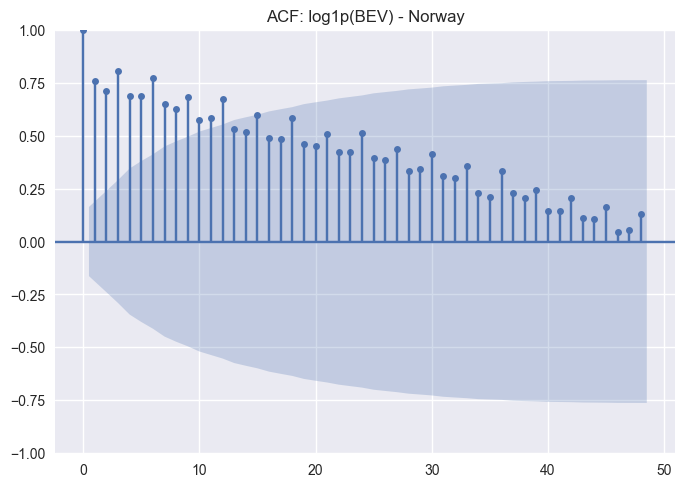

<Figure size 800x550 with 0 Axes>

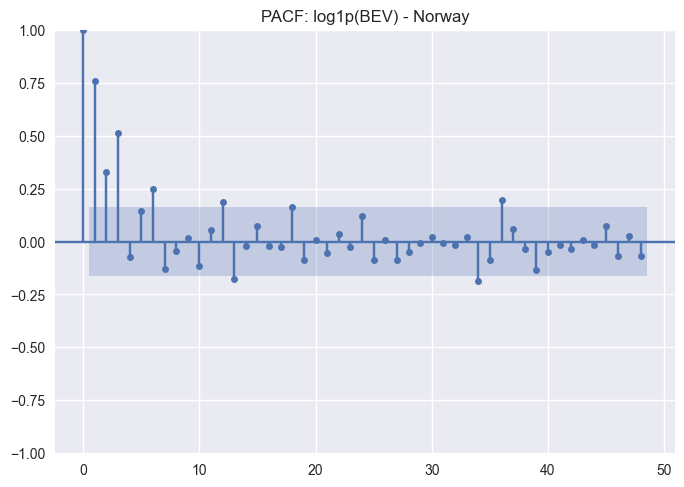

<Figure size 800x550 with 0 Axes>

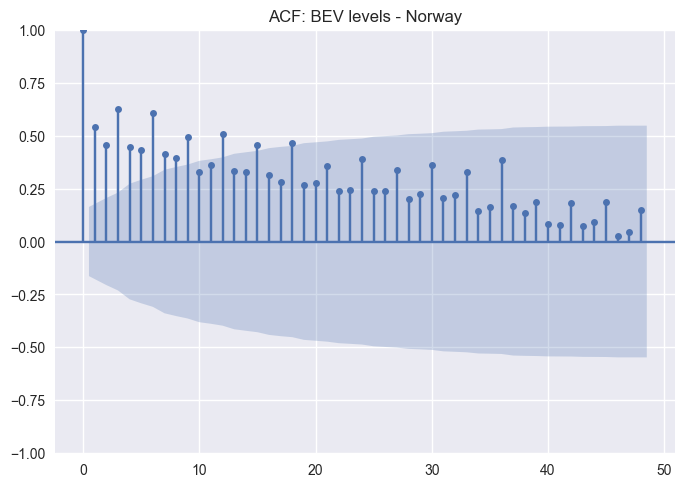

<Figure size 800x550 with 0 Axes>

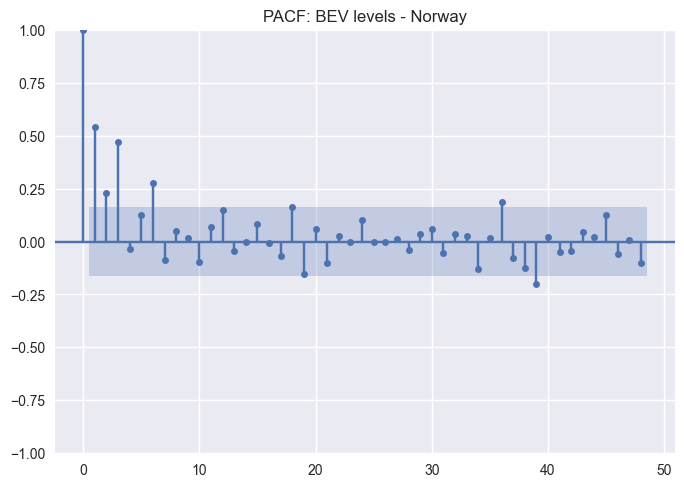

In [21]:
x = ts_log.dropna()

plt.figure()
plot_acf(x, lags=48)
plt.title("ACF: log1p(BEV)")
plt.show()

plt.figure()
plot_pacf(x, lags=48, method="ywm")
plt.title("PACF: log1p(BEV)")
plt.show()

x_raw = ts.dropna()

plt.figure()
plot_acf(x_raw, lags=48)
plt.title("ACF: BEV levels")
plt.show()

plt.figure()
plot_pacf(x_raw, lags=48, method="ywm")
plt.title("PACF: BEV levels")
plt.show()


#Norway
x_2 = ts_log_2.dropna()

plt.figure()
plot_acf(x_2, lags=48)
plt.title("ACF: log1p(BEV) - Norway")
plt.show()
plt.figure()
plot_pacf(x_2, lags=48, method="ywm")
plt.title("PACF: log1p(BEV) - Norway")
plt.show()

x_raw_2 = ts_2.dropna()

plt.figure()
plot_acf(x_raw_2, lags=48)
plt.title("ACF: BEV levels - Norway")
plt.show()

plt.figure()
plot_pacf(x_raw_2, lags=48, method="ywm")
plt.title("PACF: BEV levels - Norway")
plt.show()

### Outliers

In [22]:
z = (x - x.rolling(12, min_periods=6).mean()) / x.rolling(12, min_periods=6).std()
outliers = z[np.abs(z) > 2.5]

print("Potential shock months (|z|>2.5):")
print(outliers)


Potential shock months (|z|>2.5):
date
2025-08-01   -2.532904
Freq: MS, Name: bev, dtype: float64


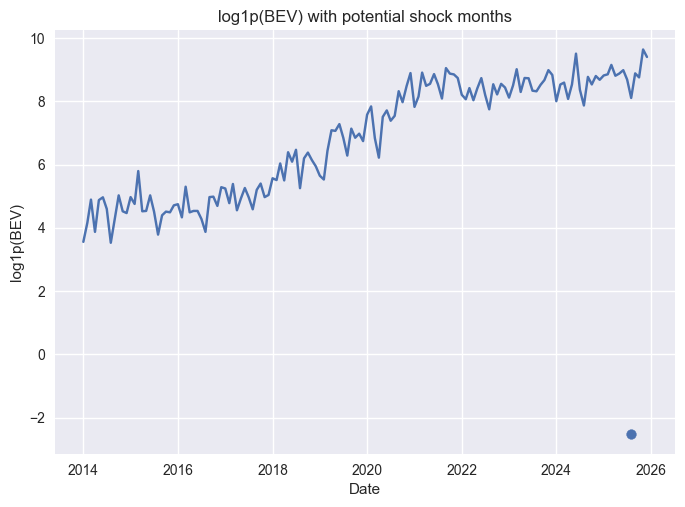

In [23]:
plt.figure()
plt.plot(x.index, x.values)
plt.scatter(outliers.index, outliers.values, marker="o")
plt.title("log1p(BEV) with potential shock months")
plt.xlabel("Date")
plt.ylabel("log1p(BEV)")
plt.show()


### BASS MODEL

In [ ]:
def bass_flow(p, q, m, T):
    """Bass expected flow (monthly new adopters) for t=1..T"""
    s = np.zeros(T, dtype=float)
    Y_cum = 0.0
    for t in range(T):
        F_prev = Y_cum / m
        s_t = m * (p + q * F_prev) * (1 - F_prev)
        s_t = max(s_t, 1e-12)
        s[t] = s_t
        Y_cum = min(Y_cum + s_t, m * (1 - 1e-9))
    return s

def fit_bass_on_log1p_flow(ts_bev: pd.Series, train_end: str):
    """Fit Bass by minimizing MSE between log1p(observed flow) and log1p(predicted flow)"""
    ts_bev = ts_bev.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end]
    y = np.log1p(train.values)
    bev = train.values
    T = len(train)

    cum_obs = float(np.sum(bev))
    p0, q0 = 0.01, 0.4
    m0 = max(cum_obs * 1.5, 1.0)

    bounds = [
        (1e-6, 1.0),            # p
        (1e-6, 5.0),            # q
        (cum_obs * 1.01, cum_obs * 200.0 + 1e6)  # m
    ]

    def obj(theta):
        p, q, m = theta
        s_hat = bass_flow(p, q, m, T)
        y_hat = np.log1p(s_hat)
        return float(np.mean((y - y_hat) ** 2))

    res = minimize(obj, x0=np.array([p0, q0, m0]), bounds=bounds, method="L-BFGS-B")
    p_hat, q_hat, m_hat = res.x
    return {"p": float(p_hat), "q": float(q_hat), "m": float(m_hat), "success": bool(res.success), "fun": float(res.fun)}

def bass_predict_log1p_train(ts_bev: pd.Series, params: dict, train_end: str):
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T = len(train)
    s_hat = bass_flow(params["p"], params["q"], params["m"], T)
    return pd.Series(np.log1p(s_hat), index=train.index)

def bass_forecast_log1p(ts_bev: pd.Series, params: dict, train_end: str, horizon: int):
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T_train = len(train)

    s_train_hat = bass_flow(params["p"], params["q"], params["m"], T_train)
    Y_cum = float(np.sum(s_train_hat))
    Y_cum = min(Y_cum, params["m"] * (1 - 1e-9))

    s_fore = np.zeros(horizon, dtype=float)
    for h in range(horizon):
        F_prev = Y_cum / params["m"]
        s_h = params["m"] * (params["p"] + params["q"] * F_prev) * (1 - F_prev)
        s_h = max(s_h, 1e-12)
        s_fore[h] = s_h
        Y_cum = min(Y_cum + s_h, params["m"] * (1 - 1e-9))

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx = pd.date_range(start=start, periods=horizon, freq="MS")
    return pd.Series(np.log1p(s_fore), index=idx)

## RAW

def fit_bass_on_raw_flow_wmse(ts_bev: pd.Series, train_end: str, eps=50.0):
    """
    Weighted MSE: weights = 1/(y+eps)
    """
    ts_bev = ts_bev.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end]

    y = train.values.astype(float)
    T = len(train)

    cum_obs = float(np.sum(y))
    p0, q0 = 0.01, 0.4
    m0 = max(cum_obs * 1.5, 1.0)

    bounds = [
        (1e-6, 1.0),
        (1e-6, 5.0),
        (cum_obs * 1.01, cum_obs * 200.0 + 1e6)
    ]

    w = 1.0 / (y + eps)

    def obj(theta):
        p, q, m = theta
        s_hat = bass_flow(p, q, m, T)
        return float(np.mean(w * (y - s_hat) ** 2))

    res = minimize(obj, x0=np.array([p0, q0, m0]), bounds=bounds, method="L-BFGS-B")
    p_hat, q_hat, m_hat = res.x
    return {
        "p": float(p_hat), "q": float(q_hat), "m": float(m_hat),
        "success": bool(res.success), "fun": float(res.fun)
    }

def bass_predict_train_raw(ts_bev: pd.Series, params: dict, train_end: str):
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T = len(train)
    s_hat = bass_flow(params["p"], params["q"], params["m"], T)
    return pd.Series(s_hat, index=train.index)

def bass_forecast_raw(ts_bev: pd.Series, params: dict, train_end: str, horizon: int):
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T_train = len(train)

    # use predicted training flows for consistent cumulative state
    s_train_hat = bass_flow(params["p"], params["q"], params["m"], T_train)
    Y_cum = float(np.sum(s_train_hat))
    Y_cum = min(Y_cum, params["m"] * (1 - 1e-9))

    s_fore = np.zeros(horizon, dtype=float)
    for h in range(horizon):
        F_prev = Y_cum / params["m"]
        s_h = params["m"] * (params["p"] + params["q"] * F_prev) * (1 - F_prev)
        s_h = max(s_h, 1e-12)
        s_fore[h] = s_h
        Y_cum = min(Y_cum + s_h, params["m"] * (1 - 1e-9))

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx = pd.date_range(start=start, periods=horizon, freq="MS")
    return pd.Series(s_fore, index=idx)


## Dynamic Market Potential

In [ ]:
def M_exp(t, M0, gamma):
    """Exponential market potential: M_t = M0 * exp(gamma * t)"""
    return M0 * np.exp(gamma * t)

def M_logistic(t, M_min, M_max, k, t0):
    return M_min + (M_max - M_min) / (1.0 + np.exp(-k * (t - t0)))
def bass_dynamic_flow(p, q, M_t):
    T = len(M_t)
    s = np.zeros(T, dtype=float)
    Y = 0.0 

    for t in range(T):
        Mt = max(M_t[t], 1e-9)
        Mt_prev = max(M_t[t-1], 1e-9) if t > 0 else Mt

        F_prev = min(max(Y / Mt_prev, 0.0), 1.0)
        s_t = (p + q * F_prev) * (Mt - Y)

        s_t = max(s_t, 1e-12)
        s[t] = s_t
        Y = min(Y + s_t, Mt * (1 - 1e-9))

    return s

def fit_dynamic_bass_logisticM(ts_flow: pd.Series, train_end: str,
                                  k_max=0.05, t0_lo=0.1, t0_hi=0.9,
                                  reg=1e-8):
    ts_flow = ts_flow.dropna().astype(float)
    train_end = pd.to_datetime(train_end)
    train = ts_flow.loc[:train_end]
    y = train.values
    T = len(train)
    t = np.arange(T, dtype=float)

    cum_obs = float(y.sum())
    y_max = float(y.max())

    #initial guesses
    p0, q0 = 0.001, 0.08

    M_min0 = max(cum_obs * 0.9, y_max * 12)          # not too low
    M_max0 = max(cum_obs * 1.2, y_max * 36)          

    k0  = min(0.02, k_max * 0.5)
    t00 = T * 0.5

    x0 = np.array([p0, q0, M_min0, M_max0, k0, t00], dtype=float)

    # bounds
    t0_lower = t0_lo * T
    t0_upper = t0_hi * T

    bounds = [
        (1e-5, 0.2),                 # p
        (1e-5, 1.5),                 # q
        (cum_obs * 0.5, cum_obs*2),  # M_min
        (cum_obs * 1.05, cum_obs*8), # M_max
        (1e-4, k_max),               # k smaller upper bound
        (t0_lower, t0_upper)         # t0
    ]

    def obj(theta):
        p, q, M_min, M_max, k, t0 = theta
        if M_max <= M_min:
            return 1e30

        M_t = M_logistic(t, M_min, M_max, k, t0)
        s_hat = bass_dynamic_flow(p, q, M_t)

        mse = np.mean((y - s_hat) ** 2)

        pen = reg * ((k / k_max) ** 2 + ((t0 - T/2) / (T/2)) ** 2)

        return float(mse + pen)

    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")

    p, q, M_min, M_max, k, t0 = res.x
    M_t = M_logistic(t, M_min, M_max, k, t0)
    s_hat = bass_dynamic_flow(p, q, M_t)

    yhat_train = pd.Series(s_hat, index=train.index)
    resid_train = train - yhat_train

    return {
        "p": float(p), "q": float(q),
        "M_min": float(M_min), "M_max": float(M_max),
        "k": float(k), "t0": float(t0),
        "success": bool(res.success), "fun": float(res.fun),
        "yhat_train": yhat_train,
        "resid_train": resid_train,
    }

def forecast_dynamic_bass_logisticM(ts_flow: pd.Series, fit: dict, train_end: str, horizon: int):
    ts_flow = ts_flow.dropna().astype(float)
    train_end = pd.to_datetime(train_end)
    train = ts_flow.loc[:train_end]
    T_train = len(train)

    p, q = fit["p"], fit["q"]
    M_min, M_max, k, t0 = fit["M_min"], fit["M_max"], fit["k"], fit["t0"]

    T_total = T_train + horizon
    t_all = np.arange(T_total, dtype=float)
    M_all = M_logistic(t_all, M_min, M_max, k, t0)

    s_all = bass_dynamic_flow(p, q, M_all)
    s_fore = s_all[T_train:]

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx = pd.date_range(start=start, periods=horizon, freq="MS")
    return pd.Series(s_fore, index=idx)



### Split + compute residuals from diffusion mean

In [ ]:
TRAIN_END = "2022-12-01"
H = 24

params = fit_bass_on_log1p_flow(ts, train_end=TRAIN_END)
print("Bass params:", params)

yhat_train = bass_predict_log1p_train(ts, params, train_end=TRAIN_END)
yhat_fore  = bass_forecast_log1p(ts, params, train_end=TRAIN_END, horizon=H)

ts_log = np.log1p(ts).dropna()

test = ts_log[ts_log.index > pd.to_datetime(TRAIN_END)].iloc[:H]

resid_train = (ts_log.loc[yhat_train.index] - yhat_train).dropna()

##Raw

params_raw = fit_bass_on_raw_flow_wmse(ts, train_end=TRAIN_END, eps=50.0)
print("Bass params (raw):", params_raw)
yhat_train_raw = bass_predict_train_raw(ts, params_raw, train_end=TRAIN_END)
yhat_fore_raw  = bass_forecast_raw(ts, params_raw, train_end=TRAIN_END, horizon=H)
ts_raw = ts.dropna()
test_raw = ts_raw[ts_raw.index > pd.to_datetime(TRAIN_END)].iloc[:H]
resid_train_raw = (ts_raw.loc[yhat_train_raw.index] - yhat_train_raw).dropna()


### Norway

params_2 = fit_bass_on_log1p_flow(ts_2, train_end=TRAIN_END)
print("Bass params Norway:", params_2)
yhat_train_2 = bass_predict_log1p_train(ts_2, params_2, train_end=TRAIN_END)
yhat_fore_2  = bass_forecast_log1p(ts_2, params_2, train_end=TRAIN_END, horizon=H)
ts_log_2 = np.log1p(ts_2).dropna()
test_2 = ts_log_2[ts_log_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
resid_train_2 = (ts_log_2.loc[yhat_train_2.index] - yhat_train_2).dropna()

## Norway Raw

params_raw_2 = fit_bass_on_raw_flow_wmse(ts_2, train_end=TRAIN_END, eps=50.0)
print("Bass params Norway (raw):", params_raw_2)
yhat_train_raw_2 = bass_predict_train_raw(ts_2, params_raw_2, train_end=TRAIN_END)
yhat_fore_raw_2  = bass_forecast_raw(ts_2, params_raw_2, train_end=TRAIN_END, horizon=H)
ts_raw_2 = ts_2.dropna()
test_raw_2 = ts_raw_2[ts_raw_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
resid_train_raw_2 = (ts_raw_2.loc[yhat_train_raw_2.index] - yhat_train_raw_2).dropna()

Bass params: {'p': 0.00011784965274412191, 'q': 0.05693030967228811, 'm': 256123.49997808307, 'success': True, 'fun': 0.39562600548839866}
Bass params (raw): {'p': 2.8970236598388893e-05, 'q': 0.07822653114367169, 'm': 256121.64574838296, 'success': True, 'fun': 278.6158666598908}
Bass params Norway: {'p': 0.0012111667896449866, 'q': 0.03235761863412467, 'm': 801551.999995023, 'success': True, 'fun': 0.1469033690847604}
Bass params Norway (raw): {'p': 0.0008151045872609611, 'q': 0.03698409870762981, 'm': 801551.3907677364, 'success': True, 'fun': 724.0888422940008}


In [27]:
fit = fit_dynamic_bass_logisticM(ts, TRAIN_END)

T = len(ts.loc[:TRAIN_END])
t = np.arange(T)
M_t = M_logistic(t, fit["M_min"], fit["M_max"], fit["k"], fit["t0"])

print("p,q:", fit["p"], fit["q"])
print("M_min/M_max:", fit["M_min"], fit["M_max"])
print("k,t0:", fit["k"], fit["t0"])
print("M(t) start/end:", float(M_t[0]), float(M_t[-1]))
print("cum_obs:", float(ts.loc[:TRAIN_END].sum()))


p,q: 5.204571517923277e-05 0.0800792941616586
M_min/M_max: 153643.69550143546 305697.08458562527
k,t0: 0.0037106163236037526 27.219560802398636
M(t) start/end: 225834.25134926406 240842.18693368346
cum_obs: 170749.0


In [ ]:
TRAIN_END = "2022-12-01"
H = 24

# fit diffusion on Raw
dyn_fit = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_raw = dyn_fit["yhat_train"]
dyn_yhat_fore_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit, train_end=TRAIN_END, horizon=H)

# log series
ts_log = np.log1p(ts).dropna()

dyn_yhat_train_log = np.log1p(dyn_yhat_train_raw)
dyn_yhat_fore_log  = np.log1p(dyn_yhat_fore_raw)

#
train_log = ts_log.loc[dyn_yhat_train_log.index]
test_log  = ts_log.loc[dyn_yhat_fore_log.index]   # aligns automatically

# residuals log windows
dyn_resid_train_log = (train_log - dyn_yhat_train_log).dropna()

##Raw

dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
print("Italy DynamicBass params:", {k: dyn_fit_it[k] for k in ["p","q","M_min","M_max","k","t0"]})

dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]

# forecast raw
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

# actual raw series
ts_it_raw = ts.dropna().astype(float)

# align true test window
test_it_raw = ts_it_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]

# residuals on training window: e_t = y_t - yhat_t
resid_train_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()

yhat_fore_raw_2  = bass_forecast_raw(ts_2, params_raw_2, train_end=TRAIN_END, horizon=H)

ts_raw_2 = ts_2.dropna()

test_raw_2 = ts_raw_2[ts_raw_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]

resid_train_raw_2 = (ts_raw_2.loc[yhat_train_raw_2.index] - yhat_train_raw_2).dropna()

## Norway


dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
print("Norway DynamicBass params:", {k: dyn_fit_no[k] for k in ["p","q","M_min","M_max","k","t0"]})

dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]

dyn_yhat_fore_no_raw  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)

ts_no_log = np.log1p(ts_2.dropna().astype(float))

dyn_yhat_train_no_log = np.log1p(np.clip(dyn_yhat_train_no_raw, 0, None))
dyn_yhat_fore_no_log  = np.log1p(np.clip(dyn_yhat_fore_no_raw, 0, None))

test_no_log = ts_no_log.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]

resid_train_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()

##Norway Raw

dyn_fit_no_raw = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
print("Norway DynamicBass params (raw):", {k: dyn_fit_no_raw[k] for k in ["p","q","M_min","M_max","k","t0"]})

dyn_yhat_train_no_raw2 = dyn_fit_no_raw["yhat_train"]

dyn_yhat_fore_no_raw2  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no_raw, train_end=TRAIN_END, horizon=H)

ts_no_raw = ts_2.dropna().astype(float)
test_no_raw = ts_no_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]


resid_train_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw2.index] - dyn_yhat_train_no_raw2).dropna()

Italy DynamicBass params: {'p': 5.204571517923277e-05, 'q': 0.0800792941616586, 'M_min': 153643.69550143546, 'M_max': 305697.08458562527, 'k': 0.0037106163236037526, 't0': 27.219560802398636}
Norway DynamicBass params: {'p': 0.000817831065187412, 'q': 0.04282633523151428, 'M_min': 480929.9462257639, 'M_max': 1176910.8267427501, 'k': 0.05, 't0': 74.88469413891039}
Norway DynamicBass params (raw): {'p': 0.000817831065187412, 'q': 0.04282633523151428, 'M_min': 480929.9462257639, 'M_max': 1176910.8267427501, 'k': 0.05, 't0': 74.88469413891039}


### Diffusion + SARIMAX residuals

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_residual_sarimax(resid_train: pd.Series):
    # arma 1,0,1 sarixma 1,0,0
    model = SARIMAX(
        resid_train,
        order=(1,0,1),
        seasonal_order=(1,0,0,12),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    return res

sarimax_fit = fit_residual_sarimax(resid_train)

# residual forecast
resid_fore = sarimax_fit.get_forecast(steps=H).predicted_mean
resid_fore.index = yhat_fore.index  # align

# Final forecast = diffusion mean + residual forecast
y_fore_sarimax = yhat_fore + resid_fore

print("Done: diffusion + SARIMAX residual baseline")

#RAW

sarimax_fit_raw = fit_residual_sarimax(resid_train_raw)
# residual forecast
resid_fore_raw = sarimax_fit_raw.get_forecast(steps=H).predicted_mean
resid_fore_raw.index = yhat_fore_raw.index  # align
# Final forecast = diffusion mean + residual forecast
y_fore_sarimax_raw = yhat_fore_raw + resid_fore_raw
print("Done: diffusion + SARIMAX residual baseline - raw")

## Norway

sarimax_fit_2 = fit_residual_sarimax(resid_train_2)
# residual forecast
resid_fore_2 = sarimax_fit_2.get_forecast(steps=H).predicted_mean
resid_fore_2.index = yhat_fore_2.index  # align
# Final forecast = diffusion mean + residual forecast
y_fore_sarimax_2 = yhat_fore_2 + resid_fore_2
print("Done: diffusion + SARIMAX residual baseline - Norway")

#RAW Norway
sarimax_fit_raw_2 = fit_residual_sarimax(resid_train_raw_2)
# residual forecast
resid_fore_raw_2 = sarimax_fit_raw_2.get_forecast(steps=H).predicted_mean
resid_fore_raw_2.index = yhat_fore_raw_2.index  # align
# Final forecast = diffusion mean + residual forecast
y_fore_sarimax_raw_2 = yhat_fore_raw_2 + resid_fore_raw_2
print("Done: diffusion + SARIMAX residual baseline - raw - Norway")


Done: diffusion + SARIMAX residual baseline
Done: diffusion + SARIMAX residual baseline - raw
Done: diffusion + SARIMAX residual baseline - Norway
Done: diffusion + SARIMAX residual baseline - raw - Norway


In [42]:
# --- DynamicBass + SARIMAX (Italy, LOG) ---
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_it_log = np.log1p(np.clip(dyn_yhat_train_it_raw, 0, None))
dyn_yhat_fore_it_log  = np.log1p(np.clip(dyn_yhat_fore_it_raw, 0, None))

ts_it_log = np.log1p(ts.dropna().astype(float))
resid_train_dyn_it_log = (ts_it_log.loc[dyn_yhat_train_it_log.index] - dyn_yhat_train_it_log).dropna()
sarimax_fit_dyn_it_log = fit_residual_sarimax(resid_train_dyn_it_log)

resid_fore_dyn_it_log = sarimax_fit_dyn_it_log.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_log.index = dyn_yhat_fore_it_log.index  # align

y_fore_sarimax_dyn_it_log = dyn_yhat_fore_it_log + resid_fore_dyn_it_log

print("Done: DynamicBass + SARIMAX residual - Italy (log)")

# --- DynamicBass + SARIMAX (Italy, RAW) ---

ts_it_raw = ts.dropna().astype(float)
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()
sarimax_fit_dyn_it_raw = fit_residual_sarimax(resid_train_dyn_it_raw)

resid_fore_dyn_it_raw = sarimax_fit_dyn_it_raw.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_raw.index = dyn_yhat_fore_it_raw.index  # align

y_fore_sarimax_dyn_it_raw = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw

print("Done: DynamicBass + SARIMAX residual - Italy (raw)")


# --- DynamicBass + SARIMAX (Norway, LOG) ---

ts_no_log = np.log1p(ts_2.dropna().astype(float))
resid_train_dyn_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()
sarimax_fit_dyn_no_log = fit_residual_sarimax(resid_train_dyn_no_log)

resid_fore_dyn_no_log = sarimax_fit_dyn_no_log.get_forecast(steps=H).predicted_mean
resid_fore_dyn_no_log.index = dyn_yhat_fore_no_log.index  # align

y_fore_sarimax_dyn_no_log = dyn_yhat_fore_no_log + resid_fore_dyn_no_log

print("Done: DynamicBass + SARIMAX residual - Norway (log)")


# --- DynamicBass + SARIMAX (Norway, RAW) ---

ts_no_raw = ts_2.dropna().astype(float)
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()
sarimax_fit_dyn_no_raw = fit_residual_sarimax(resid_train_dyn_no_raw)

resid_fore_dyn_no_raw = sarimax_fit_dyn_no_raw.get_forecast(steps=H).predicted_mean
resid_fore_dyn_no_raw.index = dyn_yhat_fore_no_raw.index  # align

y_fore_sarimax_dyn_no_raw = dyn_yhat_fore_no_raw + resid_fore_dyn_no_raw

print("Done: DynamicBass + SARIMAX residual - Norway (raw)")

Done: DynamicBass + SARIMAX residual - Italy (log)
Done: DynamicBass + SARIMAX residual - Italy (raw)
Done: DynamicBass + SARIMAX residual - Norway (log)
Done: DynamicBass + SARIMAX residual - Norway (raw)


### Diffusion + Neural residual model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class ResidualDataset(Dataset):
    def __init__(self, resid: pd.Series, lookback=24):
        self.lookback = lookback
        self.resid = resid.values.astype(np.float32)
        self.months = resid.index.month.astype(np.int64)  #
        self.X, self.m, self.y = [], [], []
        for i in range(lookback, len(self.resid)):
            self.X.append(self.resid[i-lookback:i])      #(lookback,)
            self.m.append(self.months[i-1])             
            self.y.append(self.resid[i])                 # next residual
        self.X = np.stack(self.X)
        self.m = np.array(self.m)
        self.y = np.array(self.y).astype(np.float32)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.X[idx]).unsqueeze(-1),  #lookback 1
            torch.tensor(self.m[idx]-1),                  
            torch.tensor(self.y[idx])                     #scalar
        )


### LSTM residual model

In [ ]:
class ResidualLSTM(nn.Module):
    def __init__(self, hidden=64, month_emb=8):
        super().__init__()
        self.month_emb = nn.Embedding(12, month_emb)
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden + month_emb, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq, month_idx):
        _, (h, _) = self.lstm(x_seq)       
        h = h[-1]                          
        m = self.month_emb(month_idx)    
        out = self.head(torch.cat([h, m], dim=1))
        return out.squeeze(-1)             # (B,)


### TCN resiual model

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ResidualTCNDataset(Dataset):
    """
    Predict e_t from past residuals + calendar features.
    what comes from innputs:
      - lookback
      - lag12 residual
      - month sin/cos
    """
    def __init__(self, resid: pd.Series, lookback=36):
        resid = resid.dropna()
        self.lookback = lookback
        r = resid.values.astype(np.float32)
        months = resid.index.month.astype(np.int64)

        X = []
        y = []

        for i in range(lookback, len(r)):
            window = r[i-lookback:i] 
            #features for current step i
            m = months[i] 
            m_sin = np.sin(2*np.pi*m/12.0)
            m_cos = np.cos(2*np.pi*m/12.0)
            lag12 = r[i-12] if i-12 >= 0 else 0.0

            # concatenate extra features as additional channels later
            X.append((window, lag12, m_sin, m_cos))
            y.append(r[i])

        self.y = torch.tensor(np.array(y, dtype=np.float32))
        self.window = torch.tensor(np.stack([x[0] for x in X]).astype(np.float32))  #(N,L))
        self.lag12 = torch.tensor(np.array([x[1] for x in X], dtype=np.float32)).unsqueeze(-1)  # (N,1)
        self.m_sin = torch.tensor(np.array([x[2] for x in X], dtype=np.float32)).unsqueeze(-1)  # (N,1)
        self.m_cos = torch.tensor(np.array([x[3] for x in X], dtype=np.float32)).unsqueeze(-1)  # (N,1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        w = self.window[idx].unsqueeze(-1)
        feats = torch.cat([self.lag12[idx], self.m_sin[idx], self.m_cos[idx]], dim=-1)
        return w, feats, self.y[idx]

class CausalConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1, dropout=0.1):
        super().__init__()
        self.pad = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size=kernel, dilation=dilation)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.res = (nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        x_padded = nn.functional.pad(x, (self.pad, 0)) 
        h = self.conv(x_padded)
        h = self.act(h)
        h = self.drop(h)
        return h + self.res(x)

class ResidualTCN(nn.Module):
    def __init__(self, hidden=32, levels=4, kernel=3, dropout=0.1):
        super().__init__()
        layers = []
        in_ch = 1
        for i in range(levels):
            layers.append(CausalConvBlock(in_ch, hidden, kernel=kernel, dilation=2**i, dropout=dropout))
            in_ch = hidden
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Linear(hidden + 3, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, window, extra_feats):
        #window:(B,L,1)
        x = window.permute(0, 2, 1)  
        h = self.tcn(x)              
        h_last = h[:, :, -1]         
        out = self.head(torch.cat([h_last, extra_feats], dim=1))
        return out.squeeze(-1)


def train_tcn(resid_train: pd.Series, lookback=36, epochs=500, batch_size=16, lr=1e-3):
    ds = ResidualTCNDataset(resid_train, lookback=lookback)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)
    model = ResidualTCN(hidden=32, levels=4, kernel=3, dropout=0.15).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    for ep in range(epochs):
        model.train()
        total = 0.0
        for w, feats, y in dl:
            w = w.to(DEVICE)
            feats = feats.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(w, feats)
            loss = loss_fn(pred, y)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += float(loss.item())

        if (ep+1) % 100 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(dl):.6f}")

    return model


@torch.no_grad()
def forecast_tcn(model, resid_train: pd.Series, start_date, horizon=12, lookback=36):
    model.eval()
    history = resid_train.values.astype(np.float32).tolist()
    idx = pd.date_range(start=pd.to_datetime(start_date), periods=horizon, freq="MS")

    preds = []
    for d in idx:
        m = d.month
        m_sin = np.sin(2*np.pi*m/12.0)
        m_cos = np.cos(2*np.pi*m/12.0)
        lag12 = history[-12] if len(history) >= 12 else 0.0

        window = np.array(history[-lookback:], dtype=np.float32).reshape(1, lookback, 1)
        feats = np.array([[lag12, m_sin, m_cos]], dtype=np.float32)

        w_t = torch.from_numpy(window).to(DEVICE)
        f_t = torch.from_numpy(feats).to(DEVICE)

        r_hat = model(w_t, f_t).cpu().numpy()[0]
        preds.append(float(r_hat))
        history.append(float(r_hat))

    return pd.Series(preds, index=idx)


In [34]:
LOOKBACK = 36
tcn_model = train_tcn(resid_train, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn = forecast_tcn(tcn_model, resid_train, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)

y_fore_tcn = yhat_fore + resid_fore_tcn

#RAW

tcn_model_raw = train_tcn(resid_train_raw, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn_raw = forecast_tcn(tcn_model_raw, resid_train_raw, start_date=start_fore_date_raw, horizon=H, lookback=LOOKBACK)
y_fore_tcn_raw = yhat_fore_raw + resid_fore_tcn_raw

# Norway

tcn_model_2 = train_tcn(resid_train_2, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn_2 = forecast_tcn(tcn_model_2, resid_train_2, start_date=start_fore_date_2, horizon=H, lookback=LOOKBACK)
y_fore_tcn_2 = yhat_fore_2 + resid_fore_tcn_2

# RAW Norway

tcn_model_raw_2 = train_tcn(resid_train_raw_2, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn_raw_2 = forecast_tcn(tcn_model_raw_2, resid_train_raw_2, start_date=start_fore_date_raw_2, horizon=H, lookback=LOOKBACK)
y_fore_tcn_raw_2 = yhat_fore_raw_2 + resid_fore_tcn_raw_2


Epoch 100/800 loss=0.026851
Epoch 200/800 loss=0.008833
Epoch 300/800 loss=0.009245
Epoch 400/800 loss=0.007981
Epoch 500/800 loss=0.006766
Epoch 600/800 loss=0.002810
Epoch 700/800 loss=0.005261
Epoch 800/800 loss=0.004506
Epoch 100/800 loss=104931.020508
Epoch 200/800 loss=61232.368164
Epoch 300/800 loss=65312.787598
Epoch 400/800 loss=42576.648438
Epoch 500/800 loss=35085.839600
Epoch 600/800 loss=24357.166260
Epoch 700/800 loss=17677.557373
Epoch 800/800 loss=29652.402588
Epoch 100/800 loss=0.014429
Epoch 200/800 loss=0.006663
Epoch 300/800 loss=0.004419
Epoch 400/800 loss=0.004747
Epoch 500/800 loss=0.003361
Epoch 600/800 loss=0.002084
Epoch 700/800 loss=0.001721
Epoch 800/800 loss=0.002001
Epoch 100/800 loss=841169.843750
Epoch 200/800 loss=276907.628906
Epoch 300/800 loss=211574.261719
Epoch 400/800 loss=176412.078125
Epoch 500/800 loss=169068.970703
Epoch 600/800 loss=159248.441406
Epoch 700/800 loss=284992.632812
Epoch 800/800 loss=82608.155273


In [ ]:
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

def month_start_after(date_str: str):
    return (pd.to_datetime(date_str) + pd.DateOffset(months=1)).to_period("M").to_timestamp()

START_FORE_DATE = month_start_after(TRAIN_END)

# ---------------------------
# ITALY — DynamicBass + TCN (LOG)
# ---------------------------
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_it_log = np.log1p(np.clip(dyn_yhat_train_it_raw, 0, None))
dyn_yhat_fore_it_log  = np.log1p(np.clip(dyn_yhat_fore_it_raw, 0, None))

ts_it_log = np.log1p(ts.dropna().astype(float))
resid_train_dyn_it_log = (ts_it_log.loc[dyn_yhat_train_it_log.index] - dyn_yhat_train_it_log).dropna()

tcn_model_dyn_it_log = train_tcn(resid_train_dyn_it_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_it_log = forecast_tcn(tcn_model_dyn_it_log, resid_train_dyn_it_log, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

resid_fore_dyn_it_log.index = dyn_yhat_fore_it_log.index
y_fore_dyn_it_log_tcn = dyn_yhat_fore_it_log + resid_fore_dyn_it_log


print("Done: Italy DynamicBass + TCN (LOG)")

# ---------------------------
# ITALY — DynamicBass + TCN (RAW)
# ---------------------------
ts_it_raw = ts.dropna().astype(float)
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()

tcn_model_dyn_it_raw = train_tcn(resid_train_dyn_it_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_it_raw = forecast_tcn(tcn_model_dyn_it_raw, resid_train_dyn_it_raw, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

resid_fore_dyn_it_raw.index = dyn_yhat_fore_it_raw.index
y_fore_dyn_it_raw_tcn = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw

print("Done: Italy DynamicBass + TCN (RAW)")

# ---------------------------
# NORWAY — DynamicBass + TCN (LOG)
# ---------------------------
dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]
dyn_yhat_fore_no_raw  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_no_log = np.log1p(np.clip(dyn_yhat_train_no_raw, 0, None))
dyn_yhat_fore_no_log  = np.log1p(np.clip(dyn_yhat_fore_no_raw, 0, None))

ts_no_log = np.log1p(ts_2.dropna().astype(float))
resid_train_dyn_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()

tcn_model_dyn_no_log = train_tcn(resid_train_dyn_no_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_log = forecast_tcn(tcn_model_dyn_no_log, resid_train_dyn_no_log, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

resid_fore_dyn_no_log.index = dyn_yhat_fore_no_log.index
y_fore_dyn_no_log_tcn = dyn_yhat_fore_no_log + resid_fore_dyn_no_log

print("Done: Norway DynamicBass + TCN (LOG)")

# ---------------------------
# NORWAY — DynamicBass + TCN (RAW)
# ---------------------------
ts_no_raw = ts_2.dropna().astype(float)
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()

tcn_model_dyn_no_raw = train_tcn(resid_train_dyn_no_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_raw = forecast_tcn(tcn_model_dyn_no_raw, resid_train_dyn_no_raw, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

resid_fore_dyn_no_raw.index = dyn_yhat_fore_no_raw.index
y_fore_dyn_no_raw_tcn = dyn_yhat_fore_no_raw + resid_fore_dyn_no_raw

print("Done: Norway DynamicBass + TCN (RAW)")

Epoch 100/800 loss=0.030440
Epoch 200/800 loss=0.010785
Epoch 300/800 loss=0.007045
Epoch 400/800 loss=0.007116
Epoch 500/800 loss=0.005473
Epoch 600/800 loss=0.005451
Epoch 700/800 loss=0.005345
Epoch 800/800 loss=0.002862
Done: Italy DynamicBass + TCN (LOG)
Epoch 100/800 loss=107691.828125
Epoch 200/800 loss=81237.284180
Epoch 300/800 loss=60805.191406
Epoch 400/800 loss=35352.200684
Epoch 500/800 loss=32975.761475
Epoch 600/800 loss=20406.093994
Epoch 700/800 loss=21037.617676
Epoch 800/800 loss=31117.185303
Done: Italy DynamicBass + TCN (RAW)
Epoch 100/800 loss=0.011695
Epoch 200/800 loss=0.007169
Epoch 300/800 loss=0.009031
Epoch 400/800 loss=0.003641
Epoch 500/800 loss=0.002342
Epoch 600/800 loss=0.002384
Epoch 700/800 loss=0.001340
Epoch 800/800 loss=0.001841
Done: Norway DynamicBass + TCN (LOG)
Epoch 100/800 loss=610843.171875
Epoch 200/800 loss=333047.632812
Epoch 300/800 loss=438591.970703
Epoch 400/800 loss=158142.685547
Epoch 500/800 loss=116759.601562
Epoch 600/800 loss=17

### Train NN on residuals

In [36]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_residual_nn(resid_train: pd.Series, lookback=24, epochs=800, batch_size=32, lr=1e-3):
    ds = ResidualDataset(resid_train, lookback=lookback)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)
    model = ResidualLSTM(hidden=64, month_emb=8).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for ep in range(epochs):
        total = 0.0
        for x_seq, m_idx, y in dl:
            x_seq = x_seq.to(DEVICE)
            m_idx = m_idx.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(x_seq, m_idx)
            loss = loss_fn(pred, y)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total += float(loss.item())
        if (ep+1) % 50 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(dl):.6f}")
    return model

LOOKBACK = 24
nn_model = train_residual_nn(resid_train, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

# RAW
nn_model_raw = train_residual_nn(resid_train_raw, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

# Norway
nn_model_2 = train_residual_nn(resid_train_2, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

# RAW Norway
nn_model_raw_2 = train_residual_nn(resid_train_raw_2, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

Epoch 50/300 loss=0.105075
Epoch 100/300 loss=0.097087
Epoch 150/300 loss=0.055056
Epoch 200/300 loss=0.027056
Epoch 250/300 loss=0.008787
Epoch 300/300 loss=0.002408
Epoch 50/300 loss=1570977.312500
Epoch 100/300 loss=1204605.312500
Epoch 150/300 loss=1356176.062500
Epoch 200/300 loss=1349429.453125
Epoch 250/300 loss=1262408.406250
Epoch 300/300 loss=1127482.656250
Epoch 50/300 loss=0.038244
Epoch 100/300 loss=0.029864
Epoch 150/300 loss=0.016481
Epoch 200/300 loss=0.006883
Epoch 250/300 loss=0.003505
Epoch 300/300 loss=0.000764
Epoch 50/300 loss=16308829.750000
Epoch 100/300 loss=14988553.500000
Epoch 150/300 loss=15582617.000000
Epoch 200/300 loss=14897821.250000
Epoch 250/300 loss=13375814.500000
Epoch 300/300 loss=13520448.750000


In [ ]:

# Hyperparams
LOOKBACK = 24
EPOCHS = 300
BATCH = 32
LR = 1e-3

# ============================================================
# ITALY — DynamicBass + LSTM (LOG)
# ============================================================
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_it_log = np.log1p(np.clip(dyn_yhat_train_it_raw, 0, None))
dyn_yhat_fore_it_log  = np.log1p(np.clip(dyn_yhat_fore_it_raw, 0, None))

ts_it_log = np.log1p(ts.dropna().astype(float))
resid_train_dyn_it_log = (ts_it_log.loc[dyn_yhat_train_it_log.index] - dyn_yhat_train_it_log).dropna()

nn_model_dyn_it_log = train_residual_nn(resid_train_dyn_it_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)

print("Done: Italy DynamicBass + LSTM (LOG)")

# ============================================================
# ITALY — DynamicBass + LSTM (RAW)
# ============================================================
ts_it_raw = ts.dropna().astype(float)
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()

nn_model_dyn_it_raw = train_residual_nn(resid_train_dyn_it_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)


print("Done: Italy DynamicBass + LSTM (RAW)")

# ============================================================
# NORWAY — DynamicBass + LSTM (LOG)
# ============================================================
dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]
dyn_yhat_fore_no_raw  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_no_log = np.log1p(np.clip(dyn_yhat_train_no_raw, 0, None))
dyn_yhat_fore_no_log  = np.log1p(np.clip(dyn_yhat_fore_no_raw, 0, None))

ts_no_log = np.log1p(ts_2.dropna().astype(float))
resid_train_dyn_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()

nn_model_dyn_no_log = train_residual_nn(resid_train_dyn_no_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)

print("Done: Norway DynamicBass + LSTM (LOG)")

# ============================================================
# NORWAY — DynamicBass + LSTM (RAW)
# ============================================================
ts_no_raw = ts_2.dropna().astype(float)
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()

nn_model_dyn_no_raw = train_residual_nn(resid_train_dyn_no_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)

print("Done: Norway DynamicBass + LSTM (RAW)")

Epoch 50/300 loss=0.138702
Epoch 100/300 loss=0.100966
Epoch 150/300 loss=0.059182
Epoch 200/300 loss=0.046265
Epoch 250/300 loss=0.025412
Epoch 300/300 loss=0.009244
Done: Italy DynamicBass + LSTM (LOG)
Epoch 50/300 loss=1299075.812500
Epoch 100/300 loss=1148932.718750
Epoch 150/300 loss=1172672.562500
Epoch 200/300 loss=1105472.437500
Epoch 250/300 loss=820238.437500
Epoch 300/300 loss=747715.812500
Done: Italy DynamicBass + LSTM (RAW)
Epoch 50/300 loss=0.044652
Epoch 100/300 loss=0.026400
Epoch 150/300 loss=0.018004
Epoch 200/300 loss=0.010697
Epoch 250/300 loss=0.005489
Epoch 300/300 loss=0.002961
Done: Norway DynamicBass + LSTM (LOG)
Epoch 50/300 loss=11544166.500000
Epoch 100/300 loss=4737523.250000
Epoch 150/300 loss=4377129.750000
Epoch 200/300 loss=11353105.000000
Epoch 250/300 loss=10464898.375000
Epoch 300/300 loss=3879584.125000
Done: Norway DynamicBass + LSTM (RAW)


### Forecast residuals with NN (recursive)

In [38]:
@torch.no_grad()
def forecast_residual_nn(model, resid_train: pd.Series, start_date: pd.Timestamp, horizon=12, lookback=24):
    model.eval()
    history = resid_train.values.astype(np.float32).tolist()
    idx = pd.date_range(start=start_date, periods=horizon, freq="MS")

    preds = []
    for d in idx:
        x = np.array(history[-lookback:], dtype=np.float32).reshape(1, lookback, 1)
        m = np.array([d.month - 1], dtype=np.int64)

        x_t = torch.from_numpy(x).to(DEVICE)
        m_t = torch.from_numpy(m).to(DEVICE)
        r_hat = model(x_t, m_t).cpu().numpy()[0]

        preds.append(r_hat)
        history.append(float(r_hat))

    return pd.Series(preds, index=idx)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn = forecast_residual_nn(nn_model, resid_train, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)

y_fore_nn = yhat_fore + resid_fore_nn
print("Done: diffusion + NN residual")

# RAW
start_fore_date_raw = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn_raw = forecast_residual_nn(nn_model_raw, resid_train_raw, start_date=start_fore_date_raw, horizon=H, lookback=LOOKBACK)
y_fore_nn_raw = yhat_fore_raw + resid_fore_nn_raw
print("Done: diffusion + NN residual - raw")

# Norway
start_fore_date_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn_2 = forecast_residual_nn(nn_model_2, resid_train_2, start_date=start_fore_date_2, horizon=H, lookback=LOOKBACK)
y_fore_nn_2 = yhat_fore_2 + resid_fore_nn_2
print("Done: diffusion + NN residual - Norway")

# RAW Norway
start_fore_date_raw_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn_raw_2 = forecast_residual_nn(nn_model_raw_2, resid_train_raw_2, start_date=start_fore_date_raw_2, horizon=H, lookback=LOOKBACK)
y_fore_nn_raw_2 = yhat_fore_raw_2 + resid_fore_nn_raw_2
print("Done: diffusion + NN residual - raw - Norway")


Done: diffusion + NN residual
Done: diffusion + NN residual - raw
Done: diffusion + NN residual - Norway
Done: diffusion + NN residual - raw - Norway


In [ ]:
start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()


# ============================================================
# Italy — DynamicBass + NN residual (LOG)
#    final: y_fore_dyn_it_log_nn
# ============================================================
resid_fore_dyn_it_log_nn = forecast_residual_nn(
    nn_model_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

resid_fore_dyn_it_log_nn.index = dyn_yhat_fore_it_log.index

y_fore_dyn_it_log_nn = dyn_yhat_fore_it_log + resid_fore_dyn_it_log_nn
print("Done: DynamicBass + NN residual - Italy (log)")


# ============================================================
# Italy — DynamicBass + NN residual (RAW)
#    final: y_fore_dyn_it_raw_nn
# ============================================================
resid_fore_dyn_it_raw_nn = forecast_residual_nn(
    nn_model_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

resid_fore_dyn_it_raw_nn.index = dyn_yhat_fore_it_raw.index

y_fore_dyn_it_raw_nn = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw_nn
print("Done: DynamicBass + NN residual - Italy (raw)")


# ============================================================
# Norway — DynamicBass + NN residual (LOG)
#    final: y_fore_dyn_no_log_nn
# ============================================================
resid_fore_dyn_no_log_nn = forecast_residual_nn(
    nn_model_dyn_no_log,
    resid_train_dyn_no_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

resid_fore_dyn_no_log_nn.index = dyn_yhat_fore_no_log.index

y_fore_dyn_no_log_nn = dyn_yhat_fore_no_log + resid_fore_dyn_no_log_nn
print("Done: DynamicBass + NN residual - Norway (log)")


# ============================================================
# Norway — DynamicBass + NN residual (RAW)
#    final: y_fore_dyn_no_raw_nn
# ============================================================
resid_fore_dyn_no_raw_nn = forecast_residual_nn(
    nn_model_dyn_no_raw,
    resid_train_dyn_no_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

resid_fore_dyn_no_raw_nn.index = dyn_yhat_fore_no_raw.index

y_fore_dyn_no_raw_nn = dyn_yhat_fore_no_raw + resid_fore_dyn_no_raw_nn
print("Done: DynamicBass + NN residual - Norway (raw)")

Done: DynamicBass + NN residual - Italy (log)
Done: DynamicBass + NN residual - Italy (raw)
Done: DynamicBass + NN residual - Norway (log)
Done: DynamicBass + NN residual - Norway (raw)


### Bass-only vs +SARIMAX vs +NN

In [ ]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def eval_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": float(smape(y_true, y_pred)),
    }

y_true = test.values
y_bass = yhat_fore.loc[test.index].values
y_sar  = y_fore_sarimax.loc[test.index].values
y_nn   = y_fore_nn.loc[test.index].values
y_tcn = y_fore_tcn.loc[test.index].values

results = pd.DataFrame([
    eval_metrics(y_true, y_bass, "Bass mean only"),
    eval_metrics(y_true, y_sar,  "Bass + SARIMAX residual"),
    eval_metrics(y_true, y_nn,   "Bass + NN residual (LSTM)"),
    eval_metrics(y_true, y_tcn,  "Bass + NN residual (TCN)")
])
print(results)

# RAW
y_true_raw = test_raw.values
y_bass_raw = yhat_fore_raw.loc[test_raw.index].values
y_sar_raw  = y_fore_sarimax_raw.loc[test_raw.index].values
y_nn_raw   = y_fore_nn_raw.loc[test_raw.index].values
y_tcn_raw = y_fore_tcn_raw.loc[test_raw.index].values

results_raw = pd.DataFrame([
    eval_metrics(y_true_raw, y_bass_raw, "Bass mean only - raw"),
    eval_metrics(y_true_raw, y_sar_raw,  "Bass + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_nn_raw,   "Bass + NN residual (LSTM) - raw"),
    eval_metrics(y_true_raw, y_tcn_raw,  "Bass + NN residual (TCN) - raw")   
])
print(results_raw)


## Norway
y_true_2 = test_2.values
y_bass_2 = yhat_fore_2.loc[test_2.index].values
y_sar_2  = y_fore_sarimax_2.loc[test_2.index].values
y_nn_2   = y_fore_nn_2.loc[test_2.index].values
y_tcn_2 = y_fore_tcn_2.loc[test_2.index].values

results_2 = pd.DataFrame([
    eval_metrics(y_true_2, y_bass_2, "Bass mean only - Norway"),
    eval_metrics(y_true_2, y_sar_2,  "Bass + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_nn_2,   "Bass + NN residual (LSTM) - Norway"),
    eval_metrics(y_true_2, y_tcn_2,  "Bass + NN residual (TCN) - Norway")   
])
print(results_2)

# RAW Norway
y_true_raw_2 = test_raw_2.values
y_bass_raw_2 = yhat_fore_raw_2.loc[test_raw_2.index].values
y_sar_raw_2  = y_fore_sarimax_raw_2.loc[test_raw_2.index].values
y_nn_raw_2   = y_fore_nn_raw_2.loc[test_raw_2.index].values
y_tcn_raw_2 = y_fore_tcn_raw_2.loc[test_raw_2.index].values

results_raw_2 = pd.DataFrame([
    eval_metrics(y_true_raw_2, y_bass_raw_2, "Bass mean only - raw - Norway"),
    eval_metrics(y_true_raw_2, y_sar_raw_2,  "Bass + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_nn_raw_2,   "Bass + NN residual (LSTM) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_raw_2,  "Bass + NN residual (TCN) - raw - Norway")   
])
print(results_raw_2)

                       Model       MAE      RMSE      sMAPE
0             Bass mean only  0.476213  0.582629   5.650965
1    Bass + SARIMAX residual  0.444475  0.541680   5.264228
2  Bass + NN residual (LSTM)  0.963985  1.107149  11.990343
3   Bass + NN residual (TCN)  0.594536  0.678964   7.168918
                             Model          MAE         RMSE      sMAPE
0             Bass mean only - raw  2280.862822  3202.953607  46.533110
1    Bass + SARIMAX residual - raw  2596.011199  3408.785932  56.179752
2  Bass + NN residual (LSTM) - raw  2319.133245  3278.276155  47.599459
3   Bass + NN residual (TCN) - raw  2253.225073  2988.777864  47.336763
                                Model       MAE      RMSE      sMAPE
0             Bass mean only - Norway  0.485371  0.610933   5.501200
1    Bass + SARIMAX residual - Norway  0.351541  0.576602   3.961930
2  Bass + NN residual (LSTM) - Norway  2.268413  2.348110  22.359852
3   Bass + NN residual (TCN) - Norway  0.327688  0.553078   3.68

In [ ]:
# ============================================================
# ITALY — DynamicBass (LOG)
# ============================================================
y_true = test.values

y_dyn_it_log = dyn_yhat_fore_it_log.loc[test.index].values
y_sar_it_log = y_fore_sarimax_dyn_it_log.loc[test.index].values
y_nn_it_log  = y_fore_dyn_it_log_nn.loc[test.index].values
y_tcn_it_log = y_fore_dyn_it_log_tcn.loc[test.index].values

results_dyn_it_log = pd.DataFrame([
    eval_metrics(y_true, y_dyn_it_log, "DynamicBass mean only (LOG)"),
    eval_metrics(y_true, y_sar_it_log, "DynamicBass + SARIMAX residual (LOG)"),
    eval_metrics(y_true, y_nn_it_log,  "DynamicBass + NN residual (LSTM) (LOG)"),
    eval_metrics(y_true, y_tcn_it_log, "DynamicBass + NN residual (TCN) (LOG)")
])
print("\n=== ITALY — DynamicBass (LOG) ===")
print(results_dyn_it_log)

# ============================================================
# ITALY — DynamicBass (RAW)
# ============================================================
y_true_it_raw = test_it_raw.values

y_dyn_it_raw = dyn_yhat_fore_it_raw.loc[test_it_raw.index].values
y_sar_it_raw = y_fore_sarimax_dyn_it_raw.loc[test_it_raw.index].values
y_nn_it_raw  = y_fore_dyn_it_raw_nn.loc[test_it_raw.index].values
y_tcn_it_raw = y_fore_dyn_it_raw_tcn.loc[test_it_raw.index].values

results_dyn_it_raw = pd.DataFrame([
    eval_metrics(y_true_it_raw, y_dyn_it_raw, "DynamicBass mean only (RAW)"),
    eval_metrics(y_true_it_raw, y_sar_it_raw, "DynamicBass + SARIMAX residual (RAW)"),
    eval_metrics(y_true_it_raw, y_nn_it_raw,  "DynamicBass + NN residual (LSTM) (RAW)"),
    eval_metrics(y_true_it_raw, y_tcn_it_raw, "DynamicBass + NN residual (TCN) (RAW)")
])
print("\n=== ITALY — DynamicBass (RAW) ===")
print(results_dyn_it_raw)

# ============================================================
# NORWAY — DynamicBass (LOG)
# ============================================================
y_true_no_log = test_no_log.values

y_dyn_no_log = dyn_yhat_fore_no_log.loc[test_no_log.index].values
y_sar_no_log = y_fore_sarimax_dyn_no_log.loc[test_no_log.index].values
y_nn_no_log  = y_fore_dyn_no_log_nn.loc[test_no_log.index].values
y_tcn_no_log = y_fore_dyn_no_log_tcn.loc[test_no_log.index].values

results_dyn_no_log = pd.DataFrame([
    eval_metrics(y_true_no_log, y_dyn_no_log, "DynamicBass mean only (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_sar_no_log, "DynamicBass + SARIMAX residual (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_nn_no_log,  "DynamicBass + NN residual (LSTM) (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_tcn_no_log, "DynamicBass + NN residual (TCN) (LOG) - Norway")
])
print("\n=== NORWAY — DynamicBass (LOG) ===")
print(results_dyn_no_log)

# ============================================================
# NORWAY — DynamicBass (RAW)
# ============================================================
y_true_no_raw = test_no_raw.values

y_dyn_no_raw = dyn_yhat_fore_no_raw.loc[test_no_raw.index].values
y_sar_no_raw = y_fore_sarimax_dyn_no_raw.loc[test_no_raw.index].values
y_nn_no_raw  = y_fore_dyn_no_raw_nn.loc[test_no_raw.index].values
y_tcn_no_raw = y_fore_dyn_no_raw_tcn.loc[test_no_raw.index].values

results_dyn_no_raw = pd.DataFrame([
    eval_metrics(y_true_no_raw, y_dyn_no_raw, "DynamicBass mean only (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_sar_no_raw, "DynamicBass + SARIMAX residual (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_nn_no_raw,  "DynamicBass + NN residual (LSTM) (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_tcn_no_raw, "DynamicBass + NN residual (TCN) (RAW) - Norway")
])
print("\n=== NORWAY — DynamicBass (RAW) ===")
print(results_dyn_no_raw)

all_results = pd.concat([
    results_dyn_it_log.assign(Country="Italy", Scale="log"),
    results_dyn_it_raw.assign(Country="Italy", Scale="raw"),
    results_dyn_no_log.assign(Country="Norway", Scale="log"),
    results_dyn_no_raw.assign(Country="Norway", Scale="raw"),
], ignore_index=True)

print("\n=== ALL DynamicBass results combined ===")
print(all_results)


=== ITALY — DynamicBass (LOG) ===
                                    Model       MAE      RMSE      sMAPE
0             DynamicBass mean only (LOG)  0.909505  1.051563  11.254917
1    DynamicBass + SARIMAX residual (LOG)  0.923326  1.049884  11.432828
2  DynamicBass + NN residual (LSTM) (LOG)  1.541592  1.673526  19.963343
3   DynamicBass + NN residual (TCN) (LOG)  1.454751  1.570358  18.770604

=== ITALY — DynamicBass (RAW) ===
                                    Model          MAE         RMSE      sMAPE
0             DynamicBass mean only (RAW)  3298.250139  4064.526390  80.457468
1    DynamicBass + SARIMAX residual (RAW)  3365.747481  4029.406196  84.117781
2  DynamicBass + NN residual (LSTM) (RAW)  3160.868459  4000.387150  74.974750
3   DynamicBass + NN residual (TCN) (RAW)  3375.494716  3805.085056  95.438026

=== NORWAY — DynamicBass (LOG) ===
                                             Model       MAE      RMSE  \
0             DynamicBass mean only (LOG) - Norway  0.410848

In [44]:
print(all_results)

                                              Model          MAE         RMSE  \
0                       DynamicBass mean only (LOG)     0.909505     1.051563   
1              DynamicBass + SARIMAX residual (LOG)     0.923326     1.049884   
2            DynamicBass + NN residual (LSTM) (LOG)     1.541592     1.673526   
3             DynamicBass + NN residual (TCN) (LOG)     1.454751     1.570358   
4                       DynamicBass mean only (RAW)  3298.250139  4064.526390   
5              DynamicBass + SARIMAX residual (RAW)  3365.747481  4029.406196   
6            DynamicBass + NN residual (LSTM) (RAW)  3160.868459  4000.387150   
7             DynamicBass + NN residual (TCN) (RAW)  3375.494716  3805.085056   
8              DynamicBass mean only (LOG) - Norway     0.410848     0.612421   
9     DynamicBass + SARIMAX residual (LOG) - Norway     0.405099     0.635983   
10  DynamicBass + NN residual (LSTM) (LOG) - Norway     0.669340     0.873636   
11   DynamicBass + NN residu

### Logistic

In [ ]:
from scipy.optimize import curve_fit

def logistic_cum(t, K, r, t0):
    return K / (1.0 + np.exp(-r * (t - t0)))

def fit_logistic_on_cumulative(ts_flow: pd.Series, train_end: str):
    ts_flow = ts_flow.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_flow[ts_flow.index <= train_end]

    # cumulative adoption
    C = train.cumsum().values.astype(float)
    t = np.arange(len(C), dtype=float)

    #init
    K0 = C.max() * 1.5
    r0 = 0.05
    t00 = len(C) / 2

    popt, pcov = curve_fit(
        logistic_cum, t, C,
        p0=[K0, r0, t00],
        bounds=([C.max()*1.01, 1e-5, 0], [C.max()*1000 + 1e9, 5.0, len(C)*5]),
        maxfev=20000
    )
    K, r, t0 = popt
    return {"K": float(K), "r": float(r), "t0": float(t0)}


In [ ]:
def logistic_mean_log1p_flow(ts_flow: pd.Series, params: dict, train_end: str, horizon: int):
    """
      yhat_train: fitted log1p(flow) on train index
      yhat_fore:  forecast log1p(flow) for horizon months after train_end
    """
    ts_flow = ts_flow.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_flow[ts_flow.index <= train_end]
    T_train = len(train)

    # time indexes for cumulative curve
    t_train = np.arange(T_train, dtype=float)
    t_fore  = np.arange(T_train, T_train + horizon, dtype=float)

    # cumulative predictions
    C_hat_train = logistic_cum(t_train, params["K"], params["r"], params["t0"])
    C_hat_fore  = logistic_cum(t_fore,  params["K"], params["r"], params["t0"])

    # convert to flows: s_t = C_t - C_{t-1}
    s_hat_train = np.diff(np.concatenate([[0.0], C_hat_train]))
    s_hat_fore  = np.diff(np.concatenate([[C_hat_train[-1]], C_hat_fore]))

    # avoid negatives due to numeric issues
    s_hat_train = np.maximum(s_hat_train, 1e-12)
    s_hat_fore  = np.maximum(s_hat_fore, 1e-12)

    yhat_train = pd.Series(np.log1p(s_hat_train), index=train.index)

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx_fore = pd.date_range(start=start, periods=horizon, freq="MS")
    yhat_fore = pd.Series(np.log1p(s_hat_fore), index=idx_fore)

    return yhat_train, yhat_fore

def logistic_mean_raw_flow(ts_flow: pd.Series, params: dict, train_end: str, horizon: int):
    """
      yhat_train: fitted FLOW (raw) on train index
      yhat_fore:  forecast FLOW (raw) for horizon months after train_end
    """
    ts_flow = ts_flow.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_flow[ts_flow.index <= train_end]
    T_train = len(train)

    t_train = np.arange(T_train, dtype=float)
    t_fore  = np.arange(T_train, T_train + horizon, dtype=float)

    C_hat_train = logistic_cum(t_train, params["K"], params["r"], params["t0"])
    C_hat_fore  = logistic_cum(t_fore,  params["K"], params["r"], params["t0"])
    s_hat_train = np.diff(np.concatenate([[0.0], C_hat_train]))
    s_hat_fore  = np.diff(np.concatenate([[C_hat_train[-1]], C_hat_fore]))

    #avoid negatives
    s_hat_train = np.maximum(s_hat_train, 1e-12)
    s_hat_fore  = np.maximum(s_hat_fore, 1e-12)

    #return raw fl
    yhat_train = pd.Series(s_hat_train, index=train.index)

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx_fore = pd.date_range(start=start, periods=horizon, freq="MS")
    yhat_fore = pd.Series(s_hat_fore, index=idx_fore)

    return yhat_train, yhat_fore



In [ ]:
TRAIN_END = "2022-12-01"
H = 24

#logistic mean
log_params = fit_logistic_on_cumulative(ts, train_end=TRAIN_END)
print("Logistic params:", log_params)

yhat_train_log, yhat_fore_log = logistic_mean_log1p_flow(ts, log_params, train_end=TRAIN_END, horizon=H)

#residuals log scal
ts_log = np.log1p(ts).dropna()
resid_train_log = (ts_log.loc[yhat_train_log.index] - yhat_train_log).dropna()

test = ts_log[ts_log.index > pd.to_datetime(TRAIN_END)].iloc[:H]

#SARIMAX baseline
from statsmodels.tsa.statespace.sarimax import SARIMAX

sar_model = SARIMAX(
    resid_train_log,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

resid_fore_sar = sar_model.get_forecast(steps=H).predicted_mean
resid_fore_sar.index = yhat_fore_log.index
y_fore_log_sar = yhat_fore_log + resid_fore_sar

# TCN resid
tcn_model = train_tcn(resid_train_log, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn = forecast_tcn(tcn_model, resid_train_log, start_date=yhat_fore_log.index[0], horizon=H, lookback=36)
y_fore_log_tcn = yhat_fore_log + resid_fore_tcn

# RAW

#mean
log_params_raw = fit_logistic_on_cumulative(ts, train_end=TRAIN_END)
print("Logistic params (raw):", log_params_raw)
yhat_train_raw, yhat_fore_raw = logistic_mean_raw_flow(ts, log_params_raw, train_end=TRAIN_END, horizon=H)
#series
ts_raw = ts.dropna()
test_raw = ts_raw[ts_raw.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# Rresdi e_t = y_t - yhat_t
resid_train_raw = (ts_raw.loc[yhat_train_raw.index] - yhat_train_raw).dropna()
#SARIMAX
sar_model_raw = SARIMAX(
    resid_train_raw,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
resid_fore_sar_raw = sar_model_raw.get_forecast(steps=H).predicted_mean
resid_fore_sar_raw.index = yhat_fore_raw.index
y_fore_raw_sar = yhat_fore_raw + resid_fore_sar_raw
# TCN resid
tcn_model_raw = train_tcn(resid_train_raw, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn_raw = forecast_tcn(tcn_model_raw, resid_train_raw, start_date=yhat_fore_raw.index[0], horizon=H, lookback=36)
y_fore_raw_tcn = yhat_fore_raw + resid_fore_tcn_raw


## Norway
log_params_2 = fit_logistic_on_cumulative(ts_2, train_end=TRAIN_END)
print("Logistic params Norway:", log_params_2)
yhat_train_log_2, yhat_fore_log_2 = logistic_mean_log1p_flow(ts_2, log_params_2, train_end=TRAIN_END, horizon=H)
ts_log_2 = np.log1p(ts_2).dropna()
resid_train_log_2 = (ts_log_2.loc[yhat_train_log_2.index] - yhat_train_log_2).dropna()
test_2 = ts_log_2[ts_log_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
sar_model_2 = SARIMAX(
    resid_train_log_2,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
resid_fore_sar_2 = sar_model_2.get_forecast(steps=H).predicted_mean
resid_fore_sar_2.index = yhat_fore_log_2.index
y_fore_log_sar_2 = yhat_fore_log_2 + resid_fore_sar_2

tcn_model_2 = train_tcn(resid_train_log_2, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn_2 = forecast_tcn(tcn_model_2, resid_train_log_2, start_date=yhat_fore_log_2.index[0], horizon=H, lookback=36)
y_fore_log_tcn_2 = yhat_fore_log_2 + resid_fore_tcn_2

# RAW Norway
log_params_raw_2 = fit_logistic_on_cumulative(ts_2, train_end=TRAIN_END)
print("Logistic params Norway (raw):", log_params_raw_2)
yhat_train_raw_2, yhat_fore_raw_2 = logistic_mean_raw_flow(ts_2, log_params_raw_2, train_end=TRAIN_END, horizon=H)
ts_raw_2 = ts_2.dropna()
test_raw_2 = ts_raw_2[ts_raw_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
resid_train_raw_2 = (ts_raw_2.loc[yhat_train_raw_2.index] - yhat_train_raw_2).dropna()
# SARIMAX
sar_model_raw_2 = SARIMAX(
    resid_train_raw_2,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
resid_fore_sar_raw_2 = sar_model_raw_2.get_forecast(steps=H).predicted_mean
resid_fore_sar_raw_2.index = yhat_fore_raw_2.index
y_fore_raw_sar_2 = yhat_fore_raw_2 + resid_fore_sar_raw_2
# tcn
tcn_model_raw_2 = train_tcn(resid_train_raw_2, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn_raw_2 = forecast_tcn(tcn_model_raw_2, resid_train_raw_2, start_date=yhat_fore_raw_2.index[0], horizon=H, lookback=36)
y_fore_raw_tcn_2 = yhat_fore_raw_2 + resid_fore_tcn_raw_2





Logistic params: {'K': 226101.73350211405, 'r': 0.09507430589672816, 't0': 94.79174899967526}
Epoch 100/600 loss=0.034122
Epoch 200/600 loss=0.011552
Epoch 300/600 loss=0.009790
Epoch 400/600 loss=0.003825
Epoch 500/600 loss=0.004419
Epoch 600/600 loss=0.005448
Logistic params (raw): {'K': 226101.73350211405, 'r': 0.09507430589672816, 't0': 94.79174899967526}
Epoch 100/600 loss=95765.066406
Epoch 200/600 loss=46574.281250
Epoch 300/600 loss=59950.082031
Epoch 400/600 loss=49949.267090
Epoch 500/600 loss=24106.373047
Epoch 600/600 loss=12624.193359
Logistic params Norway: {'K': 1256958.1518512147, 'r': 0.03535186114564394, 't0': 117.6450634085733}
Epoch 100/600 loss=0.020261
Epoch 200/600 loss=0.006858
Epoch 300/600 loss=0.005429
Epoch 400/600 loss=0.003067
Epoch 500/600 loss=0.002224
Epoch 600/600 loss=0.003638
Logistic params Norway (raw): {'K': 1256958.1518512147, 'r': 0.03535186114564394, 't0': 117.6450634085733}
Epoch 100/600 loss=540627.710938
Epoch 200/600 loss=547909.273438
Epoc

In [ ]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def eval_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": float(smape(y_true, y_pred)),
    }

y_true = test.values
y_bass = yhat_fore.loc[test.index].values
y_sar  = y_fore_sarimax.loc[test.index].values
y_nn   = y_fore_nn.loc[test.index].values
y_tcn = y_fore_tcn.loc[test.index].values
y_log_sar = y_fore_log_sar.loc[test.index].values
y_log_tcn = y_fore_log_tcn.loc[test.index].values


results = pd.DataFrame([
    eval_metrics(y_true, y_bass, "Bass mean only"),
    eval_metrics(y_true, y_sar,  "Bass + SARIMAX residual"),
    eval_metrics(y_true, y_nn,   "Bass + NN residual (LSTM)"),
    eval_metrics(y_true, y_tcn,  "Bass + NN residual (TCN)"),
    eval_metrics(y_true, y_log_sar, "Log + SARIMAX residual"),
    eval_metrics(y_true, y_log_tcn, "Log + TCN residual")  
])
print(results)

# RAW
y_true_raw = test_raw.values
y_bass_raw = yhat_fore_raw.loc[test_raw.index].values
y_sar_raw  = y_fore_sarimax_raw.loc[test_raw.index].values
y_nn_raw   = y_fore_nn_raw.loc[test_raw.index].values
y_tcn_raw = y_fore_tcn_raw.loc[test_raw.index].values
y_log_sar_raw = y_fore_raw_sar.loc[test_raw.index].values
y_log_tcn_raw = y_fore_raw_tcn.loc[test_raw.index].values

results_raw = pd.DataFrame([
    eval_metrics(y_true_raw, y_bass_raw, "Bass mean only - raw"),
    eval_metrics(y_true_raw, y_sar_raw,  "Bass + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_nn_raw,   "Bass + NN residual (LSTM) - raw"),
    eval_metrics(y_true_raw, y_tcn_raw,  "Bass + NN residual (TCN) - raw"),
    eval_metrics(y_true_raw, y_log_sar_raw, "Log + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_log_tcn_raw, "Log + TCN residual - raw")   
])
print(results_raw)

#Norway
y_true_2 = test_2.values
y_bass_2 = yhat_fore_2.loc[test_2.index].values
y_sar_2  = y_fore_sarimax_2.loc[test_2.index].values
y_nn_2   = y_fore_nn_2.loc[test_2.index].values
y_tcn_2 = y_fore_tcn_2.loc[test_2.index].values
y_log_sar_2 = y_fore_log_sar_2.loc[test_2.index].values
y_log_tcn_2 = y_fore_log_tcn_2.loc[test_2.index].values

results_2 = pd.DataFrame([
    eval_metrics(y_true_2, y_bass_2, "Bass mean only - Norway"),
    eval_metrics(y_true_2, y_sar_2,  "Bass + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_nn_2,   "Bass + NN residual (LSTM) - Norway"),
    eval_metrics(y_true_2, y_tcn_2,  "Bass + NN residual (TCN) - Norway"),
    eval_metrics(y_true_2, y_log_sar_2, "Log + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_log_tcn_2, "Log + TCN residual - Norway")  
])
print(results_2)

# RAW Norway
y_true_raw_2 = test_raw_2.values
y_bass_raw_2 = yhat_fore_raw_2.loc[test_raw_2.index].values
y_sar_raw_2  = y_fore_sarimax_raw_2.loc[test_raw_2.index].values
y_nn_raw_2   = y_fore_nn_raw_2.loc[test_raw_2.index].values
y_tcn_raw_2 = y_fore_tcn_raw_2.loc[test_raw_2.index].values
y_log_sar_raw_2 = y_fore_raw_sar_2.loc[test_raw_2.index].values
y_log_tcn_raw_2 = y_fore_raw_tcn_2.loc[test_raw_2.index].values

results_raw_2 = pd.DataFrame([
    eval_metrics(y_true_raw_2, y_bass_raw_2, "Bass mean only - raw - Norway"),
    eval_metrics(y_true_raw_2, y_sar_raw_2,  "Bass + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_nn_raw_2,   "Bass + NN residual (LSTM) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_raw_2,  "Bass + NN residual (TCN) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_log_sar_raw_2, "Log + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_log_tcn_raw_2, "Log + TCN residual - raw - Norway")   
])
print(results_raw_2)


                       Model       MAE      RMSE      sMAPE
0             Bass mean only  0.476213  0.582629   5.650965
1    Bass + SARIMAX residual  0.444475  0.541680   5.264228
2  Bass + NN residual (LSTM)  0.963985  1.107149  11.990343
3   Bass + NN residual (TCN)  0.594536  0.678964   7.168918
4     Log + SARIMAX residual  1.150991  1.301928  14.546257
5         Log + TCN residual  1.233769  1.356161  15.735673
                             Model          MAE         RMSE       sMAPE
0             Bass mean only - raw  3610.388442  4350.138761   94.115508
1    Bass + SARIMAX residual - raw  2596.011199  3408.785932   56.179752
2  Bass + NN residual (LSTM) - raw  2319.133245  3278.276155   47.599459
3   Bass + NN residual (TCN) - raw  2253.225073  2988.777864   47.336763
4     Log + SARIMAX residual - raw  3758.420016  4384.391212  101.404294
5         Log + TCN residual - raw  3701.664389  4237.420695  108.772151
                                Model       MAE      RMSE      sMAPE


### Multi-horizon TCN

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def month_sin_cos(month):
    msin = np.sin(2*np.pi*month/12.0)
    mcos = np.cos(2*np.pi*month/12.0)
    return msin, mcos

class ResidualMultiHorizonDataset(Dataset):
    """
    Input: residual window of length L (past)
    Output: next H residuals (direct multi-step)
    Features: month sin/cos for each horizon step (H x 2)
    """
    def __init__(self, resid: pd.Series, lookback=36, horizon=24):
        resid = resid.dropna()
        self.lookback = lookback
        self.horizon = horizon

        r = resid.values.astype(np.float32)
        idx = resid.index

        X = []
        F = []
        Y = []

        for t in range(lookback, len(r) - horizon):
            window = r[t-lookback:t]  
            future = r[t:t+horizon]
            future_dates = idx[t:t+horizon]
            feats = []
            for d in future_dates:
                ms, mc = month_sin_cos(d.month)
                feats.append([ms, mc])
            feats = np.array(feats, dtype=np.float32) 

            X.append(window)
            F.append(feats)
            Y.append(future)

        self.X = torch.tensor(np.stack(X), dtype=torch.float32)            
        self.F = torch.tensor(np.stack(F), dtype=torch.float32)            
        self.Y = torch.tensor(np.stack(Y), dtype=torch.float32)            

    def __len__(self): return self.Y.shape[0]
    def __getitem__(self, i):
        return self.X[i].unsqueeze(-1), self.F[i], self.Y[i]  # (L,1), (H,2), (H,)

class MultiHorizonTCN(nn.Module):
    """
    TCN encodes past residual window giving us a context vector
    """
    def __init__(self, hidden=32, levels=4, kernel=3, dropout=0.15, horizon=24):
        super().__init__()
        self.horizon = horizon

        def causal_block(in_ch, out_ch, dilation):
            pad = (kernel - 1) * dilation
            return nn.Sequential(
                nn.ConstantPad1d((pad, 0), 0.0),
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel, dilation=dilation),
                nn.ReLU(),
                nn.Dropout(dropout),
            )

        layers = []
        in_ch = 1
        for i in range(levels):
            layers.append(causal_block(in_ch, hidden, dilation=2**i))
            in_ch = hidden
        self.tcn = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.Linear(hidden + 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_window, future_feats):
        x = x_window.permute(0, 2, 1)             
        h = self.tcn(x)                           
        context = h[:, :, -1]                     
        B, H, _ = future_feats.shape
        context_rep = context.unsqueeze(1).expand(B, H, context.shape[1])  
        z = torch.cat([context_rep, future_feats], dim=-1)                 # (B,H,hidden+2)

        out = self.head(z).squeeze(-1)                                     
        return out

def train_multi_tcn(resid_train: pd.Series, lookback=36, horizon=24, epochs=800, batch_size=16, lr=1e-3):
    ds = ResidualMultiHorizonDataset(resid_train, lookback=lookback, horizon=horizon)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = MultiHorizonTCN(hidden=32, levels=4, kernel=3, dropout=0.15, horizon=horizon).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    for ep in range(epochs):
        model.train()
        total = 0.0
        for xw, ff, yy in dl:
            xw = xw.to(DEVICE)
            ff = ff.to(DEVICE)
            yy = yy.to(DEVICE)

            pred = model(xw, ff)
            loss = loss_fn(pred, yy)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += float(loss.item())

        if (ep+1) % 200 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(dl):.6f}")

    return model

@torch.no_grad()
def forecast_multi_tcn(model, resid_train: pd.Series, start_date, horizon=24, lookback=36):
    model.eval()
    history = resid_train.values.astype(np.float32)
    xw = torch.tensor(history[-lookback:], dtype=torch.float32).view(1, lookback, 1).to(DEVICE)

    idx = pd.date_range(start=pd.to_datetime(start_date), periods=horizon, freq="MS")
    feats = []
    for d in idx:
        ms, mc = month_sin_cos(d.month)
        feats.append([ms, mc])
    feats = torch.tensor(np.array(feats, dtype=np.float32)).unsqueeze(0).to(DEVICE)  # (1,H,2)

    pred = model(xw, feats).cpu().numpy().flatten()
    return pd.Series(pred, index=idx)


In [51]:
torch.manual_seed(42)
np.random.seed(42)

H = 24
LOOKBACK = 36

tcn_mh = train_multi_tcn(resid_train, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh = forecast_multi_tcn(tcn_mh, resid_train, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)

y_fore_bass_tcn_mh = yhat_fore + resid_fore_mh

# RAW
tcn_mh_raw = train_multi_tcn(resid_train_raw, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh_raw = forecast_multi_tcn(tcn_mh_raw, resid_train_raw, start_date=start_fore_date_raw, horizon=H, lookback=LOOKBACK)
y_fore_bass_tcn_mh_raw = yhat_fore_raw + resid_fore_mh_raw

## Norway
tcn_mh_2 = train_multi_tcn(resid_train_2, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh_2 = forecast_multi_tcn(tcn_mh_2, resid_train_2, start_date=start_fore_date_2, horizon=H, lookback=LOOKBACK)
y_fore_bass_tcn_mh_2 = yhat_fore_2 + resid_fore_mh_2

# RAW Norway
tcn_mh_raw_2 = train_multi_tcn(resid_train_raw_2, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh_raw_2 = forecast_multi_tcn(tcn_mh_raw_2, resid_train_raw_2, start_date=start_fore_date_raw_2, horizon=H, lookback=LOOKBACK)
y_fore_bass_tcn_mh_raw_2 = yhat_fore_raw_2 + resid_fore_mh_raw_2


Epoch 200/800 loss=0.166215
Epoch 400/800 loss=0.148071
Epoch 600/800 loss=0.142566
Epoch 800/800 loss=0.140215
Epoch 200/800 loss=1204047.333333
Epoch 400/800 loss=1200521.916667
Epoch 600/800 loss=1190333.375000
Epoch 800/800 loss=1175542.125000
Epoch 200/800 loss=0.051516
Epoch 400/800 loss=0.044714
Epoch 600/800 loss=0.043935
Epoch 800/800 loss=0.043413
Epoch 200/800 loss=4863554.833333
Epoch 400/800 loss=4859717.833333
Epoch 600/800 loss=4850828.833333
Epoch 800/800 loss=4833388.083333


In [ ]:
torch.manual_seed(42)
np.random.seed(42)

# Hyperparams

LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

# ============================================================
# Dynamic + residual series
# ============================================================

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()

# ITALY: Dynamic mean forecasts
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_mean_it_raw = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)
dyn_train_it_raw = dyn_fit_it["yhat_train"]

ts_it_raw = ts.dropna().astype(float)
test_it_raw = ts_it_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_train_it_raw.index] - dyn_train_it_raw).dropna()

ts_it_log = np.log1p(ts_it_raw)
dyn_train_it_log = np.log1p(np.clip(dyn_train_it_raw, 0, None))
dyn_mean_it_log  = np.log1p(np.clip(dyn_mean_it_raw, 0, None))
test_it_log = ts_it_log.loc[test_it_raw.index]
resid_train_dyn_it_log = (ts_it_log.loc[dyn_train_it_log.index] - dyn_train_it_log).dropna()

#NORWAY: Dynamic mean forecast
dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
dyn_mean_no_raw = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)
dyn_train_no_raw = dyn_fit_no["yhat_train"]

ts_no_raw = ts_2.dropna().astype(float)
test_no_raw = ts_no_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_train_no_raw.index] - dyn_train_no_raw).dropna()

ts_no_log = np.log1p(ts_no_raw)
dyn_train_no_log = np.log1p(np.clip(dyn_train_no_raw, 0, None))
dyn_mean_no_log  = np.log1p(np.clip(dyn_mean_no_raw, 0, None))
test_no_log = ts_no_log.loc[test_no_raw.index]
resid_train_dyn_no_log = (ts_no_log.loc[dyn_train_no_log.index] - dyn_train_no_log).dropna()

# ============================================================
#Train Multi-horizon TCN on Dynamic residuals + forecast residuals
# ============================================================

#Italy LOG
tcn_mh_dyn_it_log = train_multi_tcn(
    resid_train_dyn_it_log,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()

resid_fore_dyn_it_log = forecast_multi_tcn(
    tcn_mh_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

resid_fore_dyn_it_log = resid_fore_dyn_it_log.reindex(dyn_yhat_fore_it_log.index)

assert resid_fore_dyn_it_log.isna().sum() == 0, "Index mismatch: residual forecast not aligned to dyn mean index"

y_fore_dyn_it_log_tcn_mh = dyn_yhat_fore_it_log + resid_fore_dyn_it_log
print("Done: Italy DynamicBass + Multi-horizon TCN residual (LOG)")

#Italy RAW
tcn_mh_dyn_it_raw = train_multi_tcn(
    resid_train_dyn_it_raw,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

resid_fore_dyn_it_raw = forecast_multi_tcn(
    tcn_mh_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

resid_fore_dyn_it_raw = resid_fore_dyn_it_raw.reindex(dyn_yhat_fore_it_raw.index)

assert resid_fore_dyn_it_raw.isna().sum() == 0, "Index mismatch: residual forecast not aligned to dyn mean index"

y_fore_dyn_it_raw_tcn_mh = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw
print("Done: Italy DynamicBass + Multi-horizon TCN residual (RAW)")

#Norway LOG
tcn_mh_dyn_no_log = train_multi_tcn(resid_train_dyn_no_log, lookback=LOOKBACK, horizon=H, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_log = forecast_multi_tcn(tcn_mh_dyn_no_log, resid_train_dyn_no_log, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)
resid_fore_dyn_no_log.index = dyn_mean_no_log.index
y_fore_dyn_no_log_tcn_mh = dyn_mean_no_log + resid_fore_dyn_no_log
print("Done: Norway DynamicBass + Multi-horizon TCN residual (LOG)")

#norway RAW
tcn_mh_dyn_no_raw = train_multi_tcn(resid_train_dyn_no_raw, lookback=LOOKBACK, horizon=H, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_raw = forecast_multi_tcn(tcn_mh_dyn_no_raw, resid_train_dyn_no_raw, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)
resid_fore_dyn_no_raw.index = dyn_mean_no_raw.index
y_fore_dyn_no_raw_tcn_mh = dyn_mean_no_raw + resid_fore_dyn_no_raw
print("Done: Norway DynamicBass + Multi-horizon TCN residual (RAW)")

Epoch 200/800 loss=0.155761
Epoch 400/800 loss=0.132106
Epoch 600/800 loss=0.126908
Epoch 800/800 loss=0.123979
Done: Italy DynamicBass + Multi-horizon TCN residual (LOG)
Epoch 200/800 loss=1342624.333333
Epoch 400/800 loss=1339912.916667
Epoch 600/800 loss=1335661.375000
Epoch 800/800 loss=1333748.083333
Done: Italy DynamicBass + Multi-horizon TCN residual (RAW)
Epoch 200/800 loss=0.048323
Epoch 400/800 loss=0.041364
Epoch 600/800 loss=0.039996
Epoch 800/800 loss=0.039903
Done: Norway DynamicBass + Multi-horizon TCN residual (LOG)
Epoch 200/800 loss=4863060.500000
Epoch 400/800 loss=4860882.000000
Epoch 600/800 loss=4851337.000000
Epoch 800/800 loss=4836740.000000
Done: Norway DynamicBass + Multi-horizon TCN residual (RAW)


In [ ]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def eval_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": float(smape(y_true, y_pred)),
    }

y_true = test.values
y_bass = yhat_fore.loc[test.index].values
y_sar  = y_fore_sarimax.loc[test.index].values
y_nn   = y_fore_nn.loc[test.index].values
y_tcn = y_fore_tcn.loc[test.index].values
y_tcn_mh = y_fore_bass_tcn_mh.loc[test.index].values

results = pd.DataFrame([
    eval_metrics(y_true, y_bass, "Bass mean only"),
    eval_metrics(y_true, y_sar,  "Bass + SARIMAX residual"),
    eval_metrics(y_true, y_nn,   "Bass + NN residual (LSTM)"),
    eval_metrics(y_true, y_tcn,  "Bass + NN residual (TCN)"),
    eval_metrics(y_true, y_tcn_mh,  "Bass + Multi-horizon TCN residual")
])
print(results)

# RAW
y_true_raw = test_raw.values
y_bass_raw = yhat_fore_raw.loc[test_raw.index].values
y_sar_raw  = y_fore_sarimax_raw.loc[test_raw.index].values
y_nn_raw   = y_fore_nn_raw.loc[test_raw.index].values
y_tcn_raw = y_fore_tcn_raw.loc[test_raw.index].values
y_tcn_mh_raw = y_fore_bass_tcn_mh_raw.loc[test_raw.index].values

results_raw = pd.DataFrame([
    eval_metrics(y_true_raw, y_bass_raw, "Bass mean only - raw"),
    eval_metrics(y_true_raw, y_sar_raw,  "Bass + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_nn_raw,   "Bass + NN residual (LSTM) - raw"),
    eval_metrics(y_true_raw, y_tcn_raw,  "Bass + NN residual (TCN) - raw"),
    eval_metrics(y_true_raw, y_tcn_mh_raw,  "Bass + Multi-horizon TCN residual - raw")
])
print(results_raw)

## Norway

y_true_2 = test_2.values
y_bass_2 = yhat_fore_2.loc[test_2.index].values
y_sar_2  = y_fore_sarimax_2.loc[test_2.index].values
y_nn_2   = y_fore_nn_2.loc[test_2.index].values
y_tcn_2 = y_fore_tcn_2.loc[test_2.index].values
y_tcn_mh_2 = y_fore_bass_tcn_mh_2.loc[test_2.index].values

results_2 = pd.DataFrame([
    eval_metrics(y_true_2, y_bass_2, "Bass mean only - Norway"),
    eval_metrics(y_true_2, y_sar_2,  "Bass + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_nn_2,   "Bass + NN residual (LSTM) - Norway"),
    eval_metrics(y_true_2, y_tcn_2,  "Bass + NN residual (TCN) - Norway"),
    eval_metrics(y_true_2, y_tcn_mh_2,  "Bass + Multi-horizon TCN residual - Norway")
])
print(results_2)

# RAW Norway
y_true_raw_2 = test_raw_2.values
y_bass_raw_2 = yhat_fore_raw_2.loc[test_raw_2.index].values
y_sar_raw_2  = y_fore_sarimax_raw_2.loc[test_raw_2.index].values
y_nn_raw_2   = y_fore_nn_raw_2.loc[test_raw_2.index].values
y_tcn_raw_2 = y_fore_tcn_raw_2.loc[test_raw_2.index].values
y_tcn_mh_raw_2 = y_fore_bass_tcn_mh_raw_2.loc[test_raw_2.index].values

results_raw_2 = pd.DataFrame([
    eval_metrics(y_true_raw_2, y_bass_raw_2, "Bass mean only - raw - Norway"),
    eval_metrics(y_true_raw_2, y_sar_raw_2,  "Bass + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_nn_raw_2,   "Bass + NN residual (LSTM) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_raw_2,  "Bass + NN residual (TCN) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_mh_raw_2,  "Bass + Multi-horizon TCN residual - raw - Norway")
])
print(results_raw_2)

                               Model       MAE      RMSE      sMAPE
0                     Bass mean only  0.476213  0.582629   5.650965
1            Bass + SARIMAX residual  0.444475  0.541680   5.264228
2          Bass + NN residual (LSTM)  0.963985  1.107149  11.990343
3           Bass + NN residual (TCN)  0.594536  0.678964   7.168918
4  Bass + Multi-horizon TCN residual  0.374711  0.444122   4.446271
                                     Model          MAE         RMSE  \
0                     Bass mean only - raw  3610.388442  4350.138761   
1            Bass + SARIMAX residual - raw  2596.011199  3408.785932   
2          Bass + NN residual (LSTM) - raw  2319.133245  3278.276155   
3           Bass + NN residual (TCN) - raw  2253.225073  2988.777864   
4  Bass + Multi-horizon TCN residual - raw  3075.892315  3877.886093   

       sMAPE  
0  94.115508  
1  56.179752  
2  47.599459  
3  47.336763  
4  72.332683  
                                        Model       MAE      RMSE    

In [54]:
print(results_raw_2)

                                              Model          MAE  \
0                     Bass mean only - raw - Norway  2985.619129   
1            Bass + SARIMAX residual - raw - Norway  5575.428818   
2          Bass + NN residual (LSTM) - raw - Norway  3092.345238   
3           Bass + NN residual (TCN) - raw - Norway  7579.554145   
4  Bass + Multi-horizon TCN residual - raw - Norway  2687.948518   

           RMSE      sMAPE  
0   3728.834858  33.583895  
1   8356.955757  43.833077  
2   3923.777003  37.391316  
3  11889.720027  52.845968  
4   3354.687834  31.247554  


In [ ]:
# ============================================================
#ITALY  Dynamic(LOG)
# ============================================================
y_true = test.values

y_dyn_it_log = dyn_yhat_fore_it_log.loc[test.index].values
y_sar_it_log = y_fore_sarimax_dyn_it_log.loc[test.index].values
y_nn_it_log  = y_fore_dyn_it_log_nn.loc[test.index].values
y_tcn_it_log = y_fore_dyn_it_log_tcn.loc[test.index].values
y_tcn_mh_it_log = y_fore_dyn_it_log_tcn_mh.loc[test.index].values

results_dyn_it_log = pd.DataFrame([
    eval_metrics(y_true, y_dyn_it_log, "DynamicBass mean only (LOG)"),
    eval_metrics(y_true, y_sar_it_log, "DynamicBass + SARIMAX residual (LOG)"),
    eval_metrics(y_true, y_nn_it_log,  "DynamicBass + NN residual (LSTM) (LOG)"),
    eval_metrics(y_true, y_tcn_it_log, "DynamicBass + NN residual (TCN) (LOG)"),
    eval_metrics(y_true, y_tcn_mh_it_log, "DynamicBass + Multi-horizon TCN residual (LOG)")
])
print("\n=== ITALY — DynamicBass (LOG) ===")
print(results_dyn_it_log)

# ============================================================
#ITALYDynamic (RAW)
# ============================================================
y_true_it_raw = test_it_raw.values

y_dyn_it_raw = dyn_yhat_fore_it_raw.loc[test_it_raw.index].values
y_sar_it_raw = y_fore_sarimax_dyn_it_raw.loc[test_it_raw.index].values
y_nn_it_raw  = y_fore_dyn_it_raw_nn.loc[test_it_raw.index].values
y_tcn_it_raw = y_fore_dyn_it_raw_tcn.loc[test_it_raw.index].values
y_tcn_mh_it_raw = y_fore_dyn_it_raw_tcn_mh.loc[test_it_raw.index].values

results_dyn_it_raw = pd.DataFrame([
    eval_metrics(y_true_it_raw, y_dyn_it_raw, "DynamicBass mean only (RAW)"),
    eval_metrics(y_true_it_raw, y_sar_it_raw, "DynamicBass + SARIMAX residual (RAW)"),
    eval_metrics(y_true_it_raw, y_nn_it_raw,  "DynamicBass + NN residual (LSTM) (RAW)"),
    eval_metrics(y_true_it_raw, y_tcn_it_raw, "DynamicBass + NN residual (TCN) (RAW)"),
    eval_metrics(y_true_it_raw, y_tcn_mh_it_raw, "DynamicBass + Multi-horizon TCN residual (RAW)")
])
print("\n=== ITALY — DynamicBass (RAW) ===")
print(results_dyn_it_raw)

# ============================================================
#NORWAY — Dynamiclog
# ============================================================
y_true_no_log = test_no_log.values

y_dyn_no_log = dyn_yhat_fore_no_log.loc[test_no_log.index].values
y_sar_no_log = y_fore_sarimax_dyn_no_log.loc[test_no_log.index].values
y_nn_no_log  = y_fore_dyn_no_log_nn.loc[test_no_log.index].values
y_tcn_no_log = y_fore_dyn_no_log_tcn.loc[test_no_log.index].values
y_tcn_mh_no_log = y_fore_dyn_no_log_tcn_mh.loc[test_no_log.index].values

results_dyn_no_log = pd.DataFrame([
    eval_metrics(y_true_no_log, y_dyn_no_log, "DynamicBass mean only (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_sar_no_log, "DynamicBass + SARIMAX residual (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_nn_no_log,  "DynamicBass + NN residual (LSTM) (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_tcn_no_log, "DynamicBass + NN residual (TCN) (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_tcn_mh_no_log, "DynamicBass + Multi-horizon TCN residual (LOG) - Norway")
])
print("\n=== NORWAY — DynamicBass (LOG) ===")
print(results_dyn_no_log)

# ============================================================
#NORWAY— Dynamic(RAW)
# ============================================================
y_true_no_raw = test_no_raw.values

y_dyn_no_raw = dyn_yhat_fore_no_raw.loc[test_no_raw.index].values
y_sar_no_raw = y_fore_sarimax_dyn_no_raw.loc[test_no_raw.index].values
y_nn_no_raw  = y_fore_dyn_no_raw_nn.loc[test_no_raw.index].values
y_tcn_no_raw = y_fore_dyn_no_raw_tcn.loc[test_no_raw.index].values
y_tcn_mh_no_raw = y_fore_dyn_no_raw_tcn_mh.loc[test_no_raw.index].values

results_dyn_no_raw = pd.DataFrame([
    eval_metrics(y_true_no_raw, y_dyn_no_raw, "DynamicBass mean only (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_sar_no_raw, "DynamicBass + SARIMAX residual (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_nn_no_raw,  "DynamicBass + NN residual (LSTM) (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_tcn_no_raw, "DynamicBass + NN residual (TCN) (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_tcn_mh_no_raw, "DynamicBass + Multi-horizon TCN residual (RAW) - Norway")
])
print("\n=== NORWAY — DynamicBass (RAW) ===")
print(results_dyn_no_raw)

all_results = pd.concat([
    results_dyn_it_log.assign(Country="Italy", Scale="log"),
    results_dyn_it_raw.assign(Country="Italy", Scale="raw"),
    results_dyn_no_log.assign(Country="Norway", Scale="log"),
    results_dyn_no_raw.assign(Country="Norway", Scale="raw"),
], ignore_index=True)

print("\n=== ALL DynamicBass results combined ===")
print(all_results)


=== ITALY — DynamicBass (LOG) ===
                                            Model       MAE      RMSE  \
0                     DynamicBass mean only (LOG)  0.909505  1.051563   
1            DynamicBass + SARIMAX residual (LOG)  0.923326  1.049884   
2          DynamicBass + NN residual (LSTM) (LOG)  1.541592  1.673526   
3           DynamicBass + NN residual (TCN) (LOG)  1.454751  1.570358   
4  DynamicBass + Multi-horizon TCN residual (LOG)  1.556303  1.655546   

       sMAPE  
0  11.254917  
1  11.432828  
2  19.963343  
3  18.770604  
4  20.184242  

=== ITALY — DynamicBass (RAW) ===
                                            Model          MAE         RMSE  \
0                     DynamicBass mean only (RAW)  3298.250139  4064.526390   
1            DynamicBass + SARIMAX residual (RAW)  3365.747481  4029.406196   
2          DynamicBass + NN residual (LSTM) (RAW)  3160.868459  4000.387150   
3           DynamicBass + NN residual (TCN) (RAW)  3375.494716  3805.085056   
4  Dyn

In [56]:
print(all_results)

                                                Model          MAE  \
0                         DynamicBass mean only (LOG)     0.909505   
1                DynamicBass + SARIMAX residual (LOG)     0.923326   
2              DynamicBass + NN residual (LSTM) (LOG)     1.541592   
3               DynamicBass + NN residual (TCN) (LOG)     1.454751   
4      DynamicBass + Multi-horizon TCN residual (LOG)     1.556303   
5                         DynamicBass mean only (RAW)  3298.250139   
6                DynamicBass + SARIMAX residual (RAW)  3365.747481   
7              DynamicBass + NN residual (LSTM) (RAW)  3160.868459   
8               DynamicBass + NN residual (TCN) (RAW)  3375.494716   
9      DynamicBass + Multi-horizon TCN residual (RAW)  9294.870155   
10               DynamicBass mean only (LOG) - Norway     0.410848   
11      DynamicBass + SARIMAX residual (LOG) - Norway     0.405099   
12    DynamicBass + NN residual (LSTM) (LOG) - Norway     0.669340   
13     DynamicBass +

In [57]:
print(results_dyn_no_raw)

                                               Model          MAE  \
0               DynamicBass mean only (RAW) - Norway  3511.058709   
1      DynamicBass + SARIMAX residual (RAW) - Norway  5160.459126   
2    DynamicBass + NN residual (LSTM) (RAW) - Norway  3885.035996   
3     DynamicBass + NN residual (TCN) (RAW) - Norway  3501.795003   
4  DynamicBass + Multi-horizon TCN residual (RAW)...  2901.506689   

          RMSE      sMAPE  
0  4296.591950  37.629507  
1  7895.197123  41.800674  
2  4613.674468  40.570871  
3  4572.436871  44.118840  
4  3571.004386  33.042687  


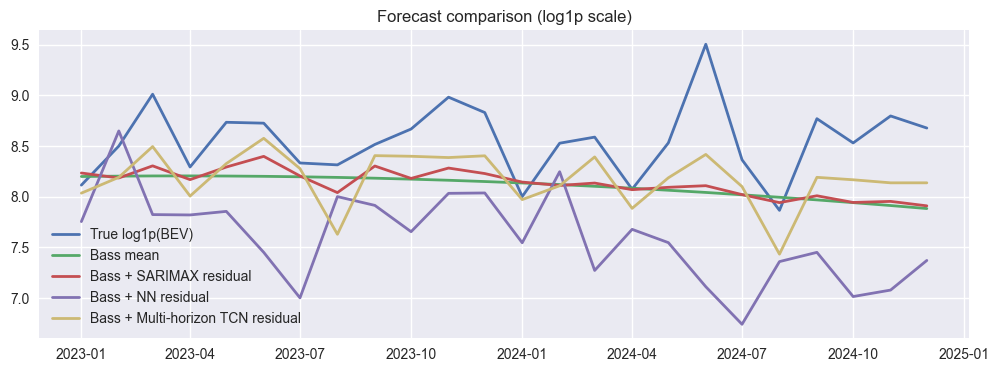

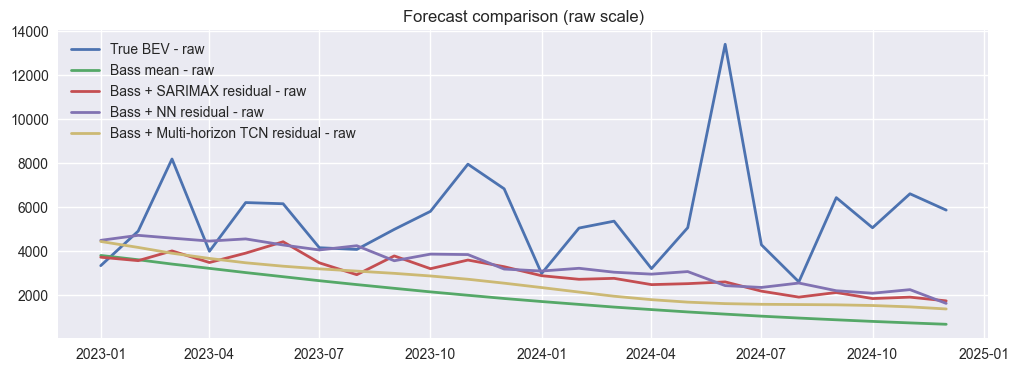

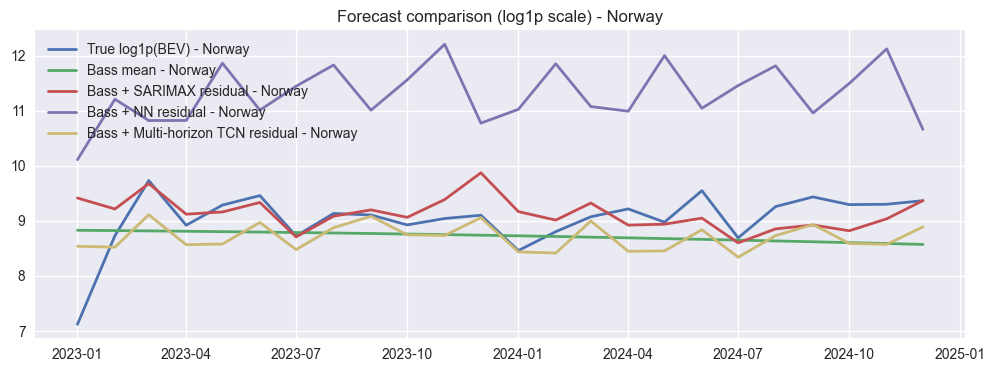

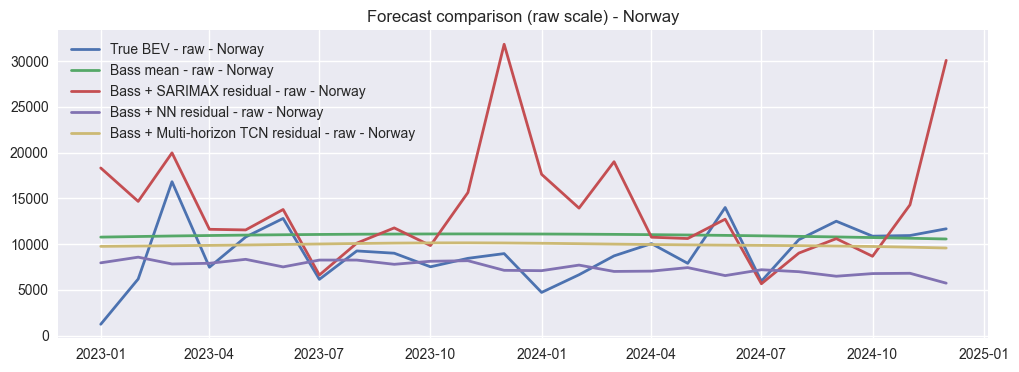

In [58]:

plt.figure(figsize=(12,4))
plt.plot(test.index, test.values, label="True log1p(BEV)", linewidth=2)
plt.plot(test.index, y_bass, label="Bass mean", linewidth=2)
plt.plot(test.index, y_sar, label="Bass + SARIMAX residual", linewidth=2)
plt.plot(test.index, y_nn, label="Bass + NN residual", linewidth=2)
plt.plot(test.index, y_tcn_mh, label="Bass + Multi-horizon TCN residual", linewidth=2)
plt.title("Forecast comparison (log1p scale)")
plt.legend()
plt.show()

# RAW
plt.figure(figsize=(12,4))
plt.plot(test_raw.index, test_raw.values, label="True BEV - raw", linewidth=2)
plt.plot(test_raw.index, y_bass_raw, label="Bass mean - raw", linewidth=2)
plt.plot(test_raw.index, y_sar_raw, label="Bass + SARIMAX residual - raw", linewidth=2)
plt.plot(test_raw.index, y_nn_raw, label="Bass + NN residual - raw", linewidth=2)
plt.plot(test_raw.index, y_tcn_mh_raw, label="Bass + Multi-horizon TCN residual - raw", linewidth=2)
plt.title("Forecast comparison (raw scale)")
plt.legend()
plt.show()

## Norway
plt.figure(figsize=(12,4))
plt.plot(test_2.index, test_2.values, label="True log1p(BEV) - Norway", linewidth=2)
plt.plot(test_2.index, y_bass_2, label="Bass mean - Norway", linewidth=2)
plt.plot(test_2.index, y_sar_2, label="Bass + SARIMAX residual - Norway", linewidth=2)
plt.plot(test_2.index, y_nn_2, label="Bass + NN residual - Norway", linewidth=2)
plt.plot(test_2.index, y_tcn_mh_2, label="Bass + Multi-horizon TCN residual - Norway", linewidth=2)
plt.title("Forecast comparison (log1p scale) - Norway")
plt.legend()
plt.show()

# RAW Norway
plt.figure(figsize=(12,4))
plt.plot(test_raw_2.index, test_raw_2.values, label="True BEV - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_bass_raw_2, label="Bass mean - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_sar_raw_2, label="Bass + SARIMAX residual - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_nn_raw_2, label="Bass + NN residual - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_tcn_mh_raw_2, label="Bass + Multi-horizon TCN residual - raw - Norway", linewidth=2)
plt.title("Forecast comparison (raw scale) - Norway")
plt.legend()
plt.show()

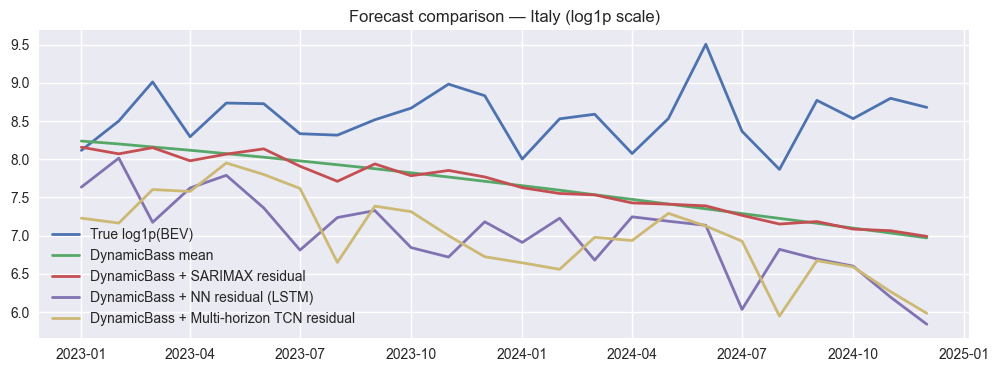

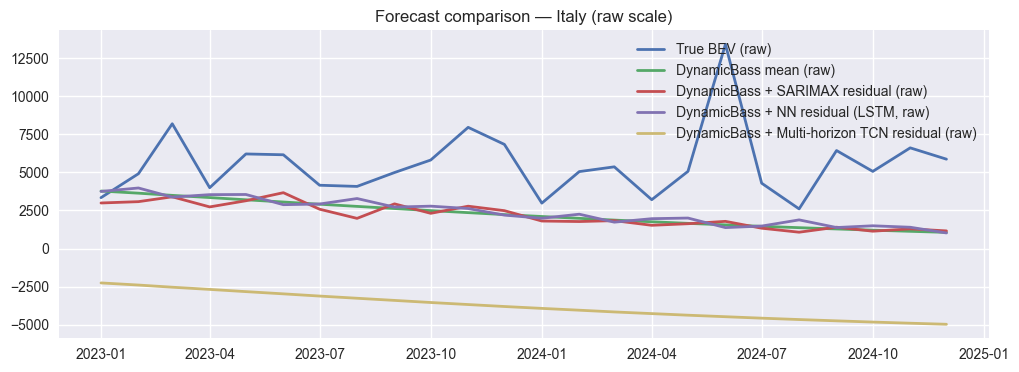

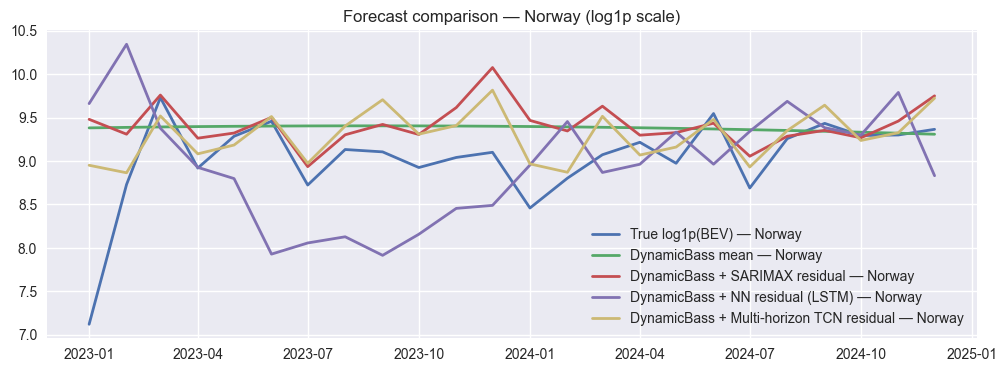

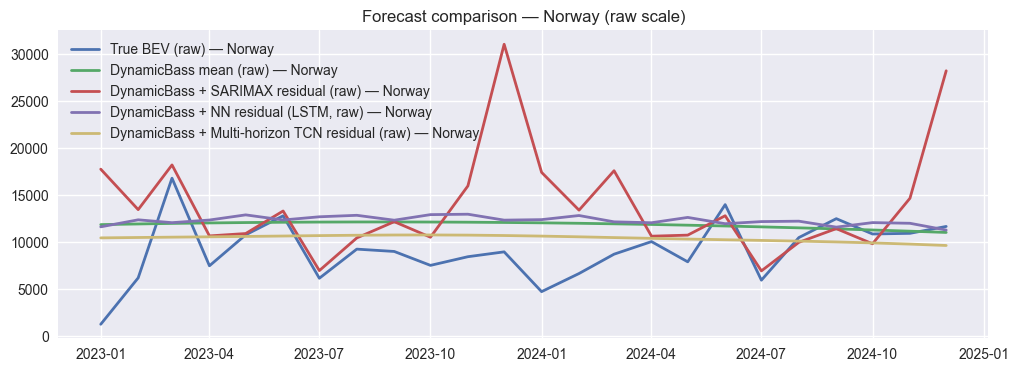

In [59]:
plt.figure(figsize=(12,4))
plt.plot(test.index, test.values, label="True log1p(BEV)", linewidth=2)

plt.plot(test.index, dyn_yhat_fore_it_log.loc[test.index].values,
         label="DynamicBass mean", linewidth=2)

plt.plot(test.index, y_fore_sarimax_dyn_it_log.loc[test.index].values,
         label="DynamicBass + SARIMAX residual", linewidth=2)

plt.plot(test.index, y_fore_dyn_it_log_nn.loc[test.index].values,
         label="DynamicBass + NN residual (LSTM)", linewidth=2)

plt.plot(test.index, y_fore_dyn_it_log_tcn_mh.loc[test.index].values,
         label="DynamicBass + Multi-horizon TCN residual", linewidth=2)

plt.title("Forecast comparison — Italy (log1p scale)")
plt.legend()
plt.show()


plt.figure(figsize=(12,4))
plt.plot(test_it_raw.index, test_it_raw.values,
         label="True BEV (raw)", linewidth=2)

plt.plot(test_it_raw.index, dyn_yhat_fore_it_raw.loc[test_it_raw.index].values,
         label="DynamicBass mean (raw)", linewidth=2)

plt.plot(test_it_raw.index, y_fore_sarimax_dyn_it_raw.loc[test_it_raw.index].values,
         label="DynamicBass + SARIMAX residual (raw)", linewidth=2)

plt.plot(test_it_raw.index, y_fore_dyn_it_raw_nn.loc[test_it_raw.index].values,
         label="DynamicBass + NN residual (LSTM, raw)", linewidth=2)

plt.plot(test_it_raw.index, y_fore_dyn_it_raw_tcn_mh.loc[test_it_raw.index].values,
         label="DynamicBass + Multi-horizon TCN residual (raw)", linewidth=2)

plt.title("Forecast comparison — Italy (raw scale)")
plt.legend()
plt.show()


plt.figure(figsize=(12,4))
plt.plot(test_no_log.index, test_no_log.values,
         label="True log1p(BEV) — Norway", linewidth=2)

plt.plot(test_no_log.index, dyn_yhat_fore_no_log.loc[test_no_log.index].values,
         label="DynamicBass mean — Norway", linewidth=2)

plt.plot(test_no_log.index, y_fore_sarimax_dyn_no_log.loc[test_no_log.index].values,
         label="DynamicBass + SARIMAX residual — Norway", linewidth=2)

plt.plot(test_no_log.index, y_fore_dyn_no_log_nn.loc[test_no_log.index].values,
         label="DynamicBass + NN residual (LSTM) — Norway", linewidth=2)

plt.plot(test_no_log.index, y_fore_dyn_no_log_tcn_mh.loc[test_no_log.index].values,
         label="DynamicBass + Multi-horizon TCN residual — Norway", linewidth=2)

plt.title("Forecast comparison — Norway (log1p scale)")
plt.legend()
plt.show()


plt.figure(figsize=(12,4))
plt.plot(test_no_raw.index, test_no_raw.values,
         label="True BEV (raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, dyn_yhat_fore_no_raw.loc[test_no_raw.index].values,
         label="DynamicBass mean (raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, y_fore_sarimax_dyn_no_raw.loc[test_no_raw.index].values,
         label="DynamicBass + SARIMAX residual (raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, y_fore_dyn_no_raw_nn.loc[test_no_raw.index].values,
         label="DynamicBass + NN residual (LSTM, raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, y_fore_dyn_no_raw_tcn_mh.loc[test_no_raw.index].values,
         label="DynamicBass + Multi-horizon TCN residual (raw) — Norway", linewidth=2)

plt.title("Forecast comparison — Norway (raw scale)")
plt.legend()
plt.show()


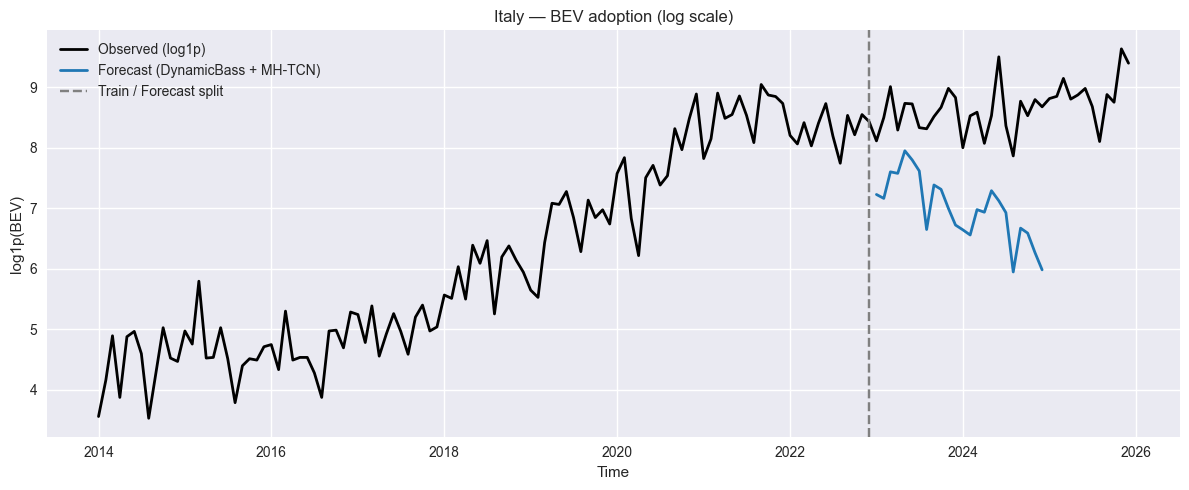

In [60]:
plt.figure(figsize=(12,5))

# Full historical data
plt.plot(ts_it_log.index, ts_it_log.values,
         label="Observed (log1p)", color="black", linewidth=2)

# Forecast (only future)
plt.plot(dyn_yhat_fore_it_log.index, y_fore_dyn_it_log_tcn_mh.values,
         label="Forecast (DynamicBass + MH-TCN)", color="tab:blue", linewidth=2)

# Train / forecast split
plt.axvline(pd.to_datetime(TRAIN_END),
            color="gray", linestyle="--", label="Train / Forecast split")

plt.title("Italy — BEV adoption (log scale)")
plt.xlabel("Time")
plt.ylabel("log1p(BEV)")
plt.legend()
plt.tight_layout()
plt.show()


Epoch 200/800 loss=0.122626
Epoch 400/800 loss=0.110335
Epoch 600/800 loss=0.108368
Epoch 800/800 loss=0.107826


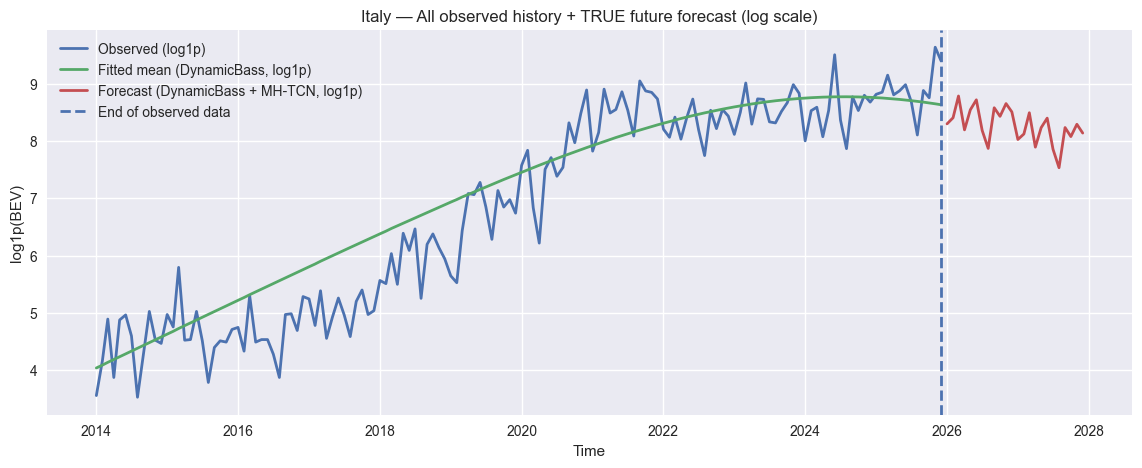

Epoch 200/800 loss=2688666.950000
Epoch 400/800 loss=2518905.200000
Epoch 600/800 loss=2670293.550000
Epoch 800/800 loss=2631296.425000


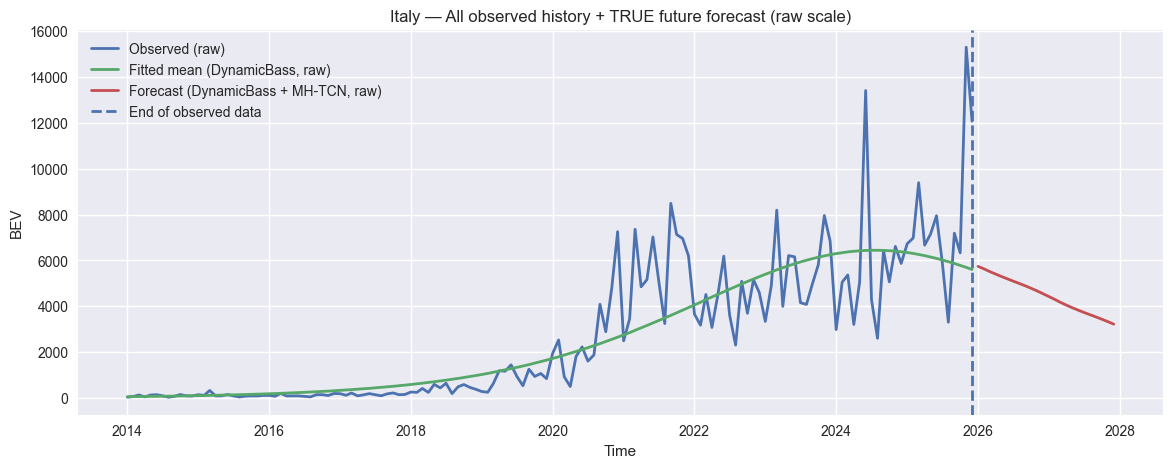

In [ ]:
H = 24
LOOKBACK = 36

ts_it = ts.dropna().astype(float)      # Italy raw series (monthly)
last_obs = ts_it.index.max()
TRAIN_END_FUTURE = last_obs            # <forecast beyond obs data
start_fore_date = (last_obs + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

# ============================================================
# ITALY — Dynamic + Multi-horizon TCN (LOG)
# ============================================================

dyn_fit_it = fit_dynamic_bass_logisticM(ts_it, train_end=TRAIN_END_FUTURE)
dyn_mean_it_raw_in = dyn_fit_it["yhat_train"] 
dyn_mean_it_raw_fc = forecast_dynamic_bass_logisticM(ts_it, dyn_fit_it, train_end=TRAIN_END_FUTURE, horizon=H)

dyn_mean_it_log_in = np.log1p(np.clip(dyn_mean_it_raw_in, 0, None))
dyn_mean_it_log_fc = np.log1p(np.clip(dyn_mean_it_raw_fc, 0, None))

ts_it_log = np.log1p(ts_it)

resid_train_dyn_it_log = (ts_it_log.loc[dyn_mean_it_log_in.index] - dyn_mean_it_log_in).dropna()

tcn_mh_dyn_it_log = train_multi_tcn(
    resid_train_dyn_it_log, lookback=LOOKBACK, horizon=H,
    epochs=800, batch_size=16, lr=1e-3
)

resid_fore_dyn_it_log = forecast_multi_tcn(
    tcn_mh_dyn_it_log, resid_train_dyn_it_log,
    start_date=start_fore_date, horizon=H, lookback=LOOKBACK
)

y_fore_dyn_it_log_tcn_mh_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log

# =========================
#      PLOT (ALL HISTORY + FUTURE)
# =========================
plt.figure(figsize=(14,5))
plt.plot(ts_it_log.index, ts_it_log.values, label="Observed (log1p)", linewidth=2)
plt.plot(dyn_mean_it_log_in.index, dyn_mean_it_log_in.values, label="Fitted mean (DynamicBass, log1p)", linewidth=2)
plt.plot(y_fore_dyn_it_log_tcn_mh_future.index, y_fore_dyn_it_log_tcn_mh_future.values,
         label="Forecast (DynamicBass + MH-TCN, log1p)", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (log scale)")
plt.xlabel("Time")
plt.ylabel("log1p(BEV)")
plt.legend()
plt.show()


# ============================================================
#ITALY — DynamicBass + Multi-horizon TCN (RAW
# ============================================================

resid_train_dyn_it_raw = (ts_it.loc[dyn_mean_it_raw_in.index] - dyn_mean_it_raw_in).dropna()

tcn_mh_dyn_it_raw = train_multi_tcn(
    resid_train_dyn_it_raw, lookback=LOOKBACK, horizon=H,
    epochs=800, batch_size=16, lr=1e-3
)

resid_fore_dyn_it_raw = forecast_multi_tcn(
    tcn_mh_dyn_it_raw, resid_train_dyn_it_raw,
    start_date=start_fore_date, horizon=H, lookback=LOOKBACK
)

y_fore_dyn_it_raw_tcn_mh_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw

plt.figure(figsize=(14,5))
plt.plot(ts_it.index, ts_it.values, label="Observed (raw)", linewidth=2)
plt.plot(dyn_mean_it_raw_in.index, dyn_mean_it_raw_in.values, label="Fitted mean (DynamicBass, raw)", linewidth=2)
plt.plot(y_fore_dyn_it_raw_tcn_mh_future.index, y_fore_dyn_it_raw_tcn_mh_future.values,
         label="Forecast (DynamicBass + MH-TCN, raw)", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.xlabel("Time")
plt.ylabel("BEV")
plt.legend()
plt.show()


Epoch 200/800 loss=2712504.650000
Epoch 400/800 loss=2681620.375000
Epoch 600/800 loss=2707647.750000
Epoch 800/800 loss=2673356.500000


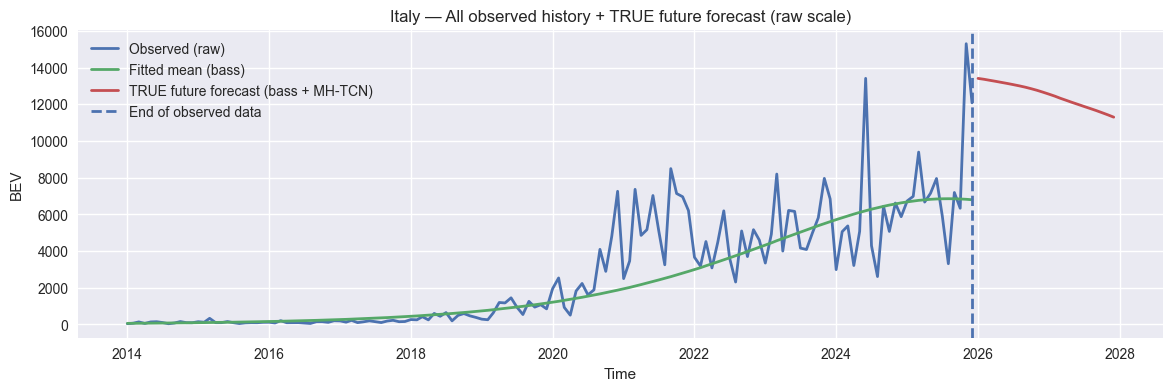

Epoch 200/800 loss=13701995.000000
Epoch 400/800 loss=12982617.400000
Epoch 600/800 loss=14171594.200000
Epoch 800/800 loss=14102729.000000


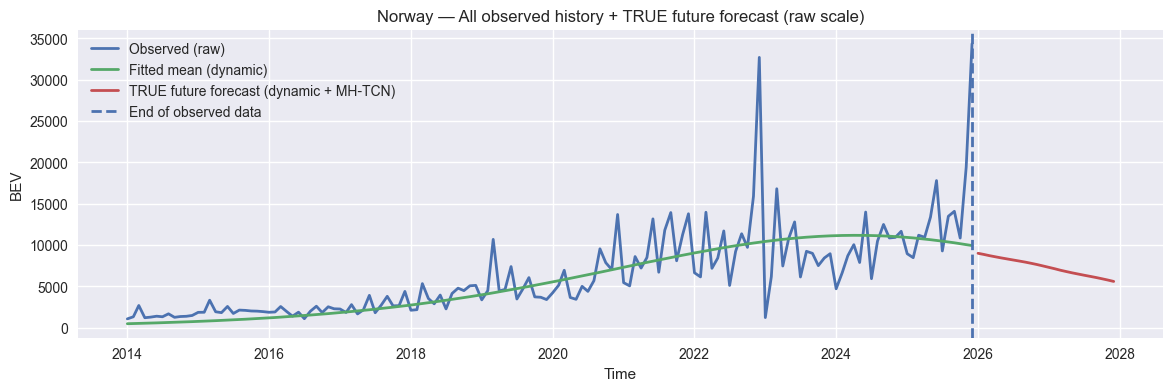

In [ ]:
H_FUTURE = 24         
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

torch.manual_seed(42)
np.random.seed(42)


italy_model = "bass"      
norway_model = "dynamic"  

#italy
ts_it = ts.dropna().astype(float)
TRAIN_END_TRUE_IT = ts_it.index.max()  # last observed month

if italy_model == "dynamic":
    dyn_fit_it = fit_dynamic_bass_logisticM(ts_it, train_end=str(TRAIN_END_TRUE_IT.date()))
    mean_train_it = dyn_fit_it["yhat_train"]  
    mean_fore_it  = forecast_dynamic_bass_logisticM(ts_it, dyn_fit_it, train_end=str(TRAIN_END_TRUE_IT.date()), horizon=H_FUTURE)
    mean_fore_it  = mean_fore_it.reindex(pd.date_range(TRAIN_END_TRUE_IT + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))
    resid_train_it = (ts_it.loc[mean_train_it.index] - mean_train_it).dropna()

else:
    params_it = fit_bass_on_raw_flow_wmse(ts_it, train_end=str(TRAIN_END_TRUE_IT.date()), eps=50.0)
    mean_train_it = bass_predict_train_raw(ts_it, params_it, train_end=str(TRAIN_END_TRUE_IT.date()))
    mean_fore_it  = bass_forecast_raw(ts_it, params_it, train_end=str(TRAIN_END_TRUE_IT.date()), horizon=H_FUTURE)
    mean_fore_it  = mean_fore_it.reindex(pd.date_range(TRAIN_END_TRUE_IT + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))
    resid_train_it = (ts_it.loc[mean_train_it.index] - mean_train_it).dropna()

tcn_mh_it = train_multi_tcn(resid_train_it, lookback=LOOKBACK, horizon=H_FUTURE, epochs=EPOCHS, batch_size=BATCH, lr=LR)
start_fore_it = (TRAIN_END_TRUE_IT + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()
resid_fore_it = forecast_multi_tcn(tcn_mh_it, resid_train_it, start_date=start_fore_it, horizon=H_FUTURE, lookback=LOOKBACK)
resid_fore_it.index = mean_fore_it.index
#finale
y_fore_it = mean_fore_it + resid_fore_it
y_fore_it = np.clip(y_fore_it, 0, None)

# Plot ITALY
plt.figure(figsize=(14,4))
plt.plot(ts_it.index, ts_it.values, label="Observed (raw)", linewidth=2)
plt.plot(mean_train_it.index, mean_train_it.values, label=f"Fitted mean ({italy_model})", linewidth=2)
plt.plot(y_fore_it.index, y_fore_it.values, label=f"TRUE future forecast ({italy_model} + MH-TCN)", linewidth=2)
plt.axvline(TRAIN_END_TRUE_IT, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.ylabel("BEV")
plt.xlabel("Time")
plt.legend()
plt.show()


#norway
ts_no = ts_2.dropna().astype(float)
TRAIN_END_TRUE_NO = ts_no.index.max()  # last observed month

if norway_model == "dynamic":
    dyn_fit_no = fit_dynamic_bass_logisticM(ts_no, train_end=str(TRAIN_END_TRUE_NO.date()))
    mean_train_no = dyn_fit_no["yhat_train"]
    mean_fore_no  = forecast_dynamic_bass_logisticM(ts_no, dyn_fit_no, train_end=str(TRAIN_END_TRUE_NO.date()), horizon=H_FUTURE)
    mean_fore_no  = mean_fore_no.reindex(pd.date_range(TRAIN_END_TRUE_NO + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))

    resid_train_no = (ts_no.loc[mean_train_no.index] - mean_train_no).dropna()

else:
    params_no = fit_bass_on_raw_flow_wmse(ts_no, train_end=str(TRAIN_END_TRUE_NO.date()), eps=50.0)
    mean_train_no = bass_predict_train_raw(ts_no, params_no, train_end=str(TRAIN_END_TRUE_NO.date()))
    mean_fore_no  = bass_forecast_raw(ts_no, params_no, train_end=str(TRAIN_END_TRUE_NO.date()), horizon=H_FUTURE)
    mean_fore_no  = mean_fore_no.reindex(pd.date_range(TRAIN_END_TRUE_NO + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))

    resid_train_no = (ts_no.loc[mean_train_no.index] - mean_train_no).dropna()

tcn_mh_no = train_multi_tcn(resid_train_no, lookback=LOOKBACK, horizon=H_FUTURE, epochs=EPOCHS, batch_size=BATCH, lr=LR)
start_fore_no = (TRAIN_END_TRUE_NO + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()
resid_fore_no = forecast_multi_tcn(tcn_mh_no, resid_train_no, start_date=start_fore_no, horizon=H_FUTURE, lookback=LOOKBACK)
resid_fore_no.index = mean_fore_no.index

y_fore_no = mean_fore_no + resid_fore_no
y_fore_no = np.clip(y_fore_no, 0, None)

# Plot NORWAY
plt.figure(figsize=(14,4))
plt.plot(ts_no.index, ts_no.values, label="Observed (raw)", linewidth=2)
plt.plot(mean_train_no.index, mean_train_no.values, label=f"Fitted mean ({norway_model})", linewidth=2)
plt.plot(y_fore_no.index, y_fore_no.values, label=f"TRUE future forecast ({norway_model} + MH-TCN)", linewidth=2)
plt.axvline(TRAIN_END_TRUE_NO, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Norway — All observed history + TRUE future forecast (raw scale)")
plt.ylabel("BEV")
plt.xlabel("Time")
plt.legend()
plt.show()


Epoch 50/300 loss=3171943.916667
Epoch 100/300 loss=3411095.666667
Epoch 150/300 loss=3118013.208333
Epoch 200/300 loss=2796157.302083
Epoch 250/300 loss=2699121.541667
Epoch 300/300 loss=2311032.583333
Epoch 50/300 loss=0.084130
Epoch 100/300 loss=0.090515
Epoch 150/300 loss=0.086983
Epoch 200/300 loss=0.049583
Epoch 250/300 loss=0.029133
Epoch 300/300 loss=0.015959
Epoch 100/800 loss=278997.476562
Epoch 200/800 loss=278402.877604
Epoch 300/800 loss=102988.602214
Epoch 400/800 loss=86043.201172
Epoch 500/800 loss=67854.716146
Epoch 600/800 loss=68925.912760
Epoch 700/800 loss=57719.921875
Epoch 800/800 loss=58023.372396
Epoch 100/800 loss=0.033211
Epoch 200/800 loss=0.019777
Epoch 300/800 loss=0.008303
Epoch 400/800 loss=0.006847
Epoch 500/800 loss=0.005945
Epoch 600/800 loss=0.006377
Epoch 700/800 loss=0.003383
Epoch 800/800 loss=0.003404
Epoch 200/800 loss=2653082.100000
Epoch 400/800 loss=2630014.775000
Epoch 600/800 loss=2611176.025000
Epoch 800/800 loss=2653880.025000
Epoch 200/8

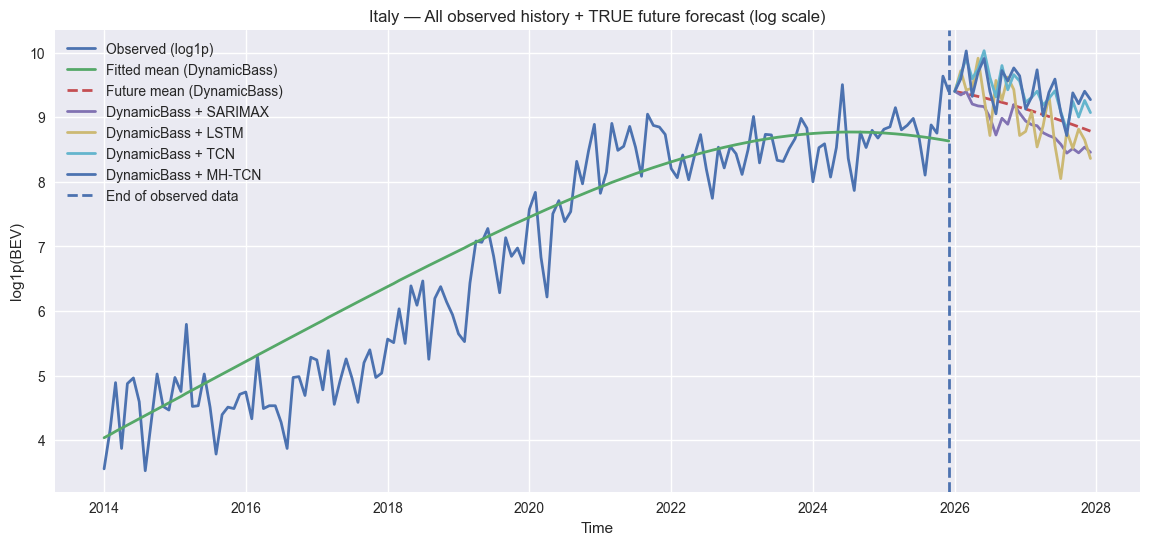

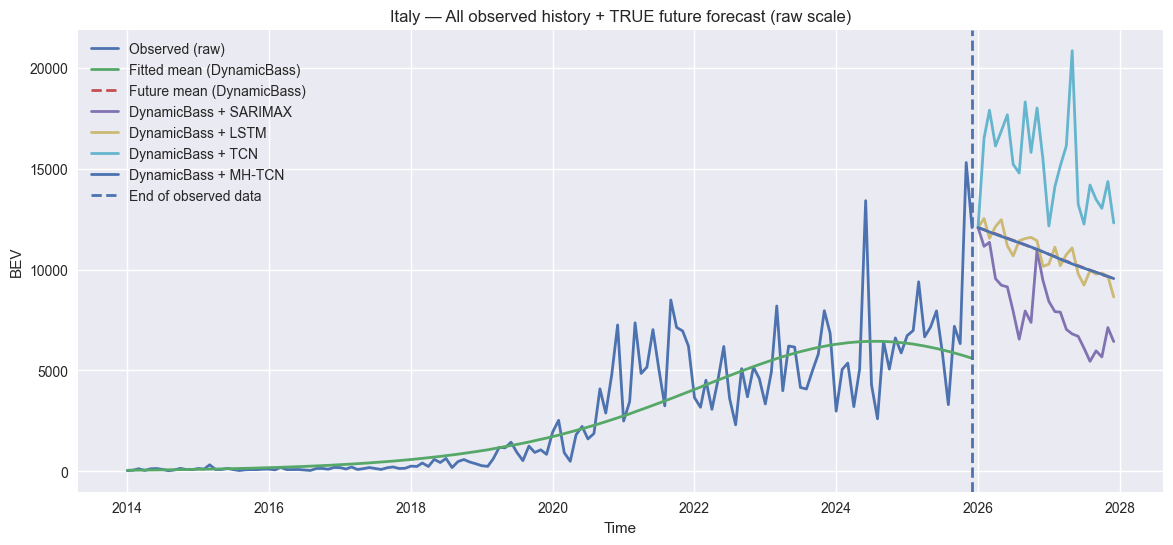

In [ ]:
H = 24
LOOKBACK = 36

ts_it = ts.dropna().astype(float)
last_obs = ts_it.index.max()
TRAIN_END_FUTURE = last_obs
start_fore_date = (last_obs + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

# ============================================================
# DYNAMIC DIFFUSION ON RAW
# ============================================================
dyn_fit_it = fit_dynamic_bass_logisticM(ts_it, train_end=TRAIN_END_FUTURE)
dyn_mean_it_raw_in = dyn_fit_it["yhat_train"]
dyn_mean_it_raw_fc = forecast_dynamic_bass_logisticM(ts_it, dyn_fit_it, train_end=TRAIN_END_FUTURE, horizon=H)

ts_it_raw = ts_it.copy()
ts_it_log = np.log1p(ts_it_raw)
dyn_mean_it_log_in = np.log1p(np.clip(dyn_mean_it_raw_in, 0, None))
dyn_mean_it_log_fc = np.log1p(np.clip(dyn_mean_it_raw_fc, 0, None))

# ============================================================
# BUILD RESIDUALS
# ============================================================

# RAW residuals
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_mean_it_raw_in.index] - dyn_mean_it_raw_in).dropna()

# LOG residuals
resid_train_dyn_it_log = (ts_it_log.loc[dyn_mean_it_log_in.index] - dyn_mean_it_log_in).dropna()

# ============================================================
# SARIMAX RESIDUAL FORECASTS
# ============================================================
sarimax_fit_dyn_it_raw = fit_residual_sarimax(resid_train_dyn_it_raw)
resid_fore_dyn_it_raw_sar = sarimax_fit_dyn_it_raw.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_raw_sar.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_sar_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_sar

sarimax_fit_dyn_it_log = fit_residual_sarimax(resid_train_dyn_it_log)
resid_fore_dyn_it_log_sar = sarimax_fit_dyn_it_log.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_log_sar.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_sar_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_sar

# ============================================================
# LSTM RESIDUAL FORECASTS
# ============================================================
LOOKBACK_LSTM = 24

nn_model_dyn_it_raw = train_residual_nn(resid_train_dyn_it_raw, lookback=LOOKBACK_LSTM, epochs=300, batch_size=32, lr=1e-3)
resid_fore_dyn_it_raw_nn = forecast_residual_nn(
    nn_model_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK_LSTM
)
resid_fore_dyn_it_raw_nn.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_nn_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_nn

nn_model_dyn_it_log = train_residual_nn(resid_train_dyn_it_log, lookback=LOOKBACK_LSTM, epochs=300, batch_size=32, lr=1e-3)
resid_fore_dyn_it_log_nn = forecast_residual_nn(
    nn_model_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK_LSTM
)
resid_fore_dyn_it_log_nn.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_nn_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_nn

# ============================================================
# TCN RESIDUAL FORECASTS
# ============================================================
tcn_model_dyn_it_raw = train_tcn(resid_train_dyn_it_raw, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_raw_tcn = forecast_tcn(
    tcn_model_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_raw_tcn.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_tcn_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_tcn

tcn_model_dyn_it_log = train_tcn(resid_train_dyn_it_log, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_log_tcn = forecast_tcn(
    tcn_model_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_log_tcn.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_tcn_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_tcn

# ============================================================
# MULTI-HORIZON TCN RESIDUAL FORECASTS
# ============================================================
tcn_mh_dyn_it_raw = train_multi_tcn(resid_train_dyn_it_raw, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_raw_mh = forecast_multi_tcn(
    tcn_mh_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_raw_mh.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_mh_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_mh

tcn_mh_dyn_it_log = train_multi_tcn(resid_train_dyn_it_log, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_log_mh = forecast_multi_tcn(
    tcn_mh_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_log_mh.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_mh_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_mh

# ============================================================
# FUTURE FORECASTS + LAST OBSERVED VALUE
# ============================================================

def anchor_forecast_to_last_observed(y_fore, observed_series):
    offset = observed_series.iloc[-1] - y_fore.iloc[0]
    return y_fore + offset

# RAW
dyn_mean_it_raw_fc_anchor      = anchor_forecast_to_last_observed(dyn_mean_it_raw_fc, ts_it_raw)
y_fore_dyn_it_raw_sar_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_sar_future, ts_it_raw)
y_fore_dyn_it_raw_nn_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_nn_future, ts_it_raw)
y_fore_dyn_it_raw_tcn_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_tcn_future, ts_it_raw)
y_fore_dyn_it_raw_mh_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_mh_future, ts_it_raw)

# LOG
dyn_mean_it_log_fc_anchor      = anchor_forecast_to_last_observed(dyn_mean_it_log_fc, ts_it_log)
y_fore_dyn_it_log_sar_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_log_sar_future, ts_it_log)
y_fore_dyn_it_log_nn_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_log_nn_future, ts_it_log)
y_fore_dyn_it_log_tcn_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_log_tcn_future, ts_it_log)
y_fore_dyn_it_log_mh_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_log_mh_future, ts_it_log)

#plott log
plt.figure(figsize=(14, 6))
plt.plot(ts_it_log.index, ts_it_log.values, label="Observed (log1p)", linewidth=2)
plt.plot(dyn_mean_it_log_in.index, dyn_mean_it_log_in.values, label="Fitted mean (DynamicBass)", linewidth=2)
plt.plot(dyn_mean_it_log_fc_anchor.index, dyn_mean_it_log_fc_anchor.values, label="Future mean (DynamicBass)", linewidth=2, linestyle="--")
plt.plot(y_fore_dyn_it_log_sar_future.index, y_fore_dyn_it_log_sar_future.values, label="DynamicBass + SARIMAX", linewidth=2)
plt.plot(y_fore_dyn_it_log_nn_future.index, y_fore_dyn_it_log_nn_future.values, label="DynamicBass + LSTM", linewidth=2)
plt.plot(y_fore_dyn_it_log_tcn_future.index, y_fore_dyn_it_log_tcn_future.values, label="DynamicBass + TCN", linewidth=2)
plt.plot(y_fore_dyn_it_log_mh_future.index, y_fore_dyn_it_log_mh_future.values, label="DynamicBass + MH-TCN", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (log scale)")
plt.xlabel("Time")
plt.ylabel("log1p(BEV)")
plt.legend()
plt.show()

#plot raw
plt.figure(figsize=(14, 6))
plt.plot(ts_it_raw.index, ts_it_raw.values, label="Observed (raw)", linewidth=2)
plt.plot(dyn_mean_it_raw_in.index, dyn_mean_it_raw_in.values, label="Fitted mean (DynamicBass)", linewidth=2)
plt.plot(dyn_mean_it_raw_fc_anchor.index, dyn_mean_it_raw_fc_anchor.values, label="Future mean (DynamicBass)", linewidth=2, linestyle="--")
plt.plot(y_fore_dyn_it_raw_sar_future.index, y_fore_dyn_it_raw_sar_future.values, label="DynamicBass + SARIMAX", linewidth=2)
plt.plot(y_fore_dyn_it_raw_nn_future.index, y_fore_dyn_it_raw_nn_future.values, label="DynamicBass + LSTM", linewidth=2)
plt.plot(y_fore_dyn_it_raw_tcn_future.index, y_fore_dyn_it_raw_tcn_future.values, label="DynamicBass + TCN", linewidth=2)
plt.plot(y_fore_dyn_it_raw_mh_future.index, y_fore_dyn_it_raw_mh_future.values, label="DynamicBass + MH-TCN", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.xlabel("Time")
plt.ylabel("BEV")
plt.legend()
plt.show()

Epoch 200/800 loss=2644312.950000
Epoch 400/800 loss=2713760.250000
Epoch 600/800 loss=2590797.750000
Epoch 800/800 loss=2657128.925000


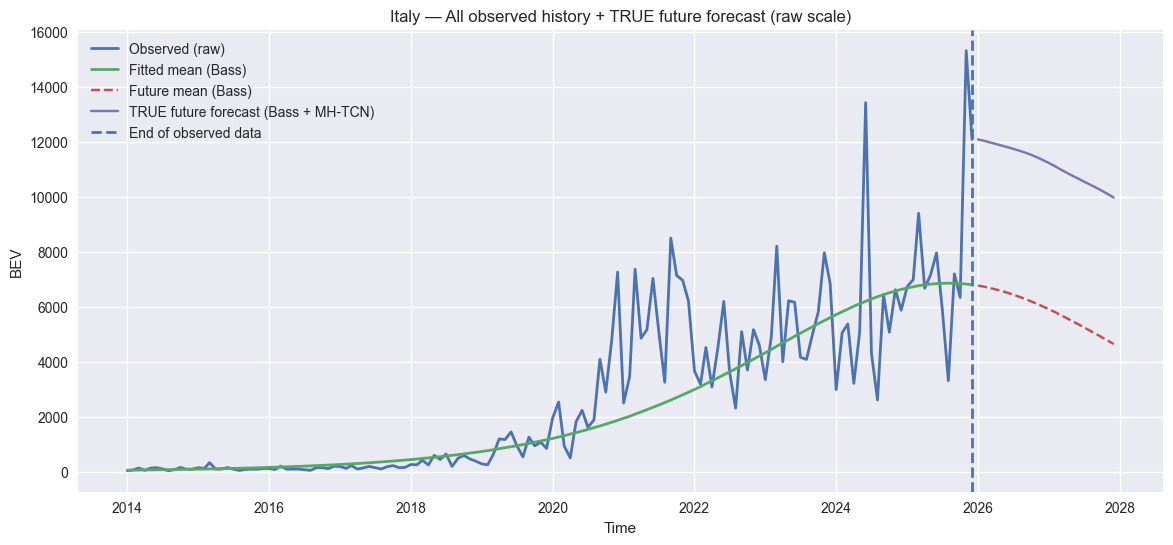

Epoch 200/800 loss=13731558.200000
Epoch 400/800 loss=13386675.600000
Epoch 600/800 loss=13763941.300000
Epoch 800/800 loss=13346014.400000


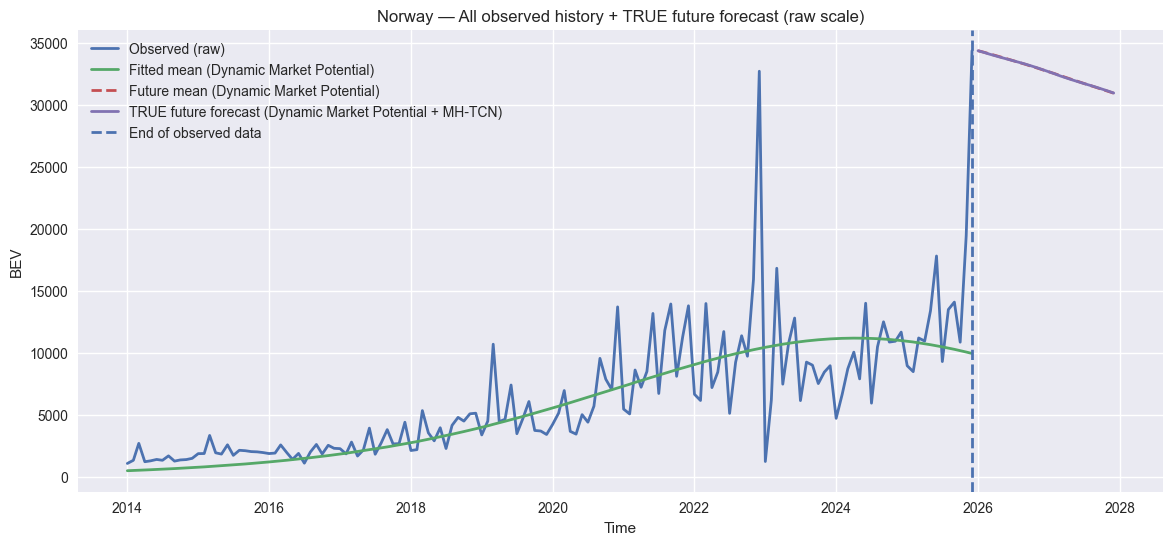

In [ ]:
H = 24
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

def anchor_forecast_to_last_observed(y_fore: pd.Series, observed_series: pd.Series):
    """
    Shift future forecast so that its first point starts at the last observed value.
    """
    offset = observed_series.iloc[-1] - y_fore.iloc[0]
    return y_fore + offset

# ============================================================
# ITALY — RAW — BEST MODEL: Bass + MH-TCN
# ============================================================
ts_it_raw = ts.dropna().astype(float)
last_obs_it = ts_it_raw.index.max()
TRAIN_END_FUTURE_IT = last_obs_it
start_fore_date_it = (last_obs_it + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

params_it_raw = fit_bass_on_raw_flow_wmse(ts_it_raw, train_end=TRAIN_END_FUTURE_IT, eps=50.0)
bass_mean_it_raw_in = bass_predict_train_raw(ts_it_raw, params_it_raw, train_end=TRAIN_END_FUTURE_IT)
bass_mean_it_raw_fc = bass_forecast_raw(ts_it_raw, params_it_raw, train_end=TRAIN_END_FUTURE_IT, horizon=H)

resid_train_it_raw = (ts_it_raw.loc[bass_mean_it_raw_in.index] - bass_mean_it_raw_in).dropna()

tcn_mh_it_raw = train_multi_tcn(
    resid_train_it_raw,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

resid_fore_it_raw_mh = forecast_multi_tcn(
    tcn_mh_it_raw,
    resid_train_it_raw,
    start_date=start_fore_date_it,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_it_raw_mh.index = bass_mean_it_raw_fc.index

y_fore_it_raw_mh_future = bass_mean_it_raw_fc + resid_fore_it_raw_mh

y_fore_it_raw_mh_future_anchor = anchor_forecast_to_last_observed(y_fore_it_raw_mh_future, ts_it_raw)

# plot italy
plt.figure(figsize=(14, 6))
plt.plot(ts_it_raw.index, ts_it_raw.values, label="Observed (raw)", linewidth=2)
plt.plot(bass_mean_it_raw_in.index, bass_mean_it_raw_in.values, label="Fitted mean (Bass)", linewidth=2)
plt.plot(bass_mean_it_raw_fc.index, bass_mean_it_raw_fc.values,
         label="Future mean (Bass)", linestyle="--")

plt.plot(y_fore_it_raw_mh_future_anchor.index, y_fore_it_raw_mh_future_anchor.values,
         label="TRUE future forecast (Bass + MH-TCN)")

plt.axvline(last_obs_it, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.xlabel("Time")
plt.ylabel("BEV")
plt.legend()
plt.show()


# ============================================================
# NORWAY — RAW — BEST MODEL: Dynamic Market Potential + MH-TCN
# ============================================================
ts_no = ts_2.dropna().astype(float)
last_obs_no = ts_no.index.max()

def anchor_forecast_to_last_observed(forecast, observed):
    offset = observed.iloc[-1] - forecast.iloc[0]
    return forecast + offset
TRAIN_END_FUTURE_NO = last_obs_no
start_fore_date_no = (last_obs_no + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

dyn_fit_no = fit_dynamic_bass_logisticM(ts_no_raw, train_end=TRAIN_END_FUTURE_NO)
dyn_mean_no_raw_in = dyn_fit_no["yhat_train"]
dyn_mean_no_raw_fc = forecast_dynamic_bass_logisticM(ts_no_raw, dyn_fit_no, train_end=TRAIN_END_FUTURE_NO, horizon=H)

resid_train_no_raw = (ts_no_raw.loc[dyn_mean_no_raw_in.index] - dyn_mean_no_raw_in).dropna()

tcn_mh_no_raw = train_multi_tcn(
    resid_train_no_raw,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

resid_fore_no_raw_mh = forecast_multi_tcn(
    tcn_mh_no_raw,
    resid_train_no_raw,
    start_date=start_fore_date_no,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_no_raw_mh.index = dyn_mean_no_raw_fc.index

sarimax_no = SARIMAX(
    resid_train_dyn_no_raw,
    order=(1,0,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


resid_fore_no_raw_sarimax = sarimax_no.forecast(steps=H)

resid_fore_no_raw_tcn = forecast_tcn(
    tcn_model_dyn_no_raw,
    resid_train_dyn_no_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)


resid_fore_no_raw_lstm = forecast_residual_nn(
    nn_model_dyn_no_raw,
    resid_train_dyn_no_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

y_fore_no_raw_lstm_future = dyn_mean_no_raw_fc + resid_fore_no_raw_lstm

# Final forecast
y_fore_no_raw_sarimax_future = dyn_mean_no_raw_fc + resid_fore_no_raw_sarimax

# Final forecast
y_fore_no_raw_tcn_future = dyn_mean_no_raw_fc + resid_fore_no_raw_tcn

#future fore
y_fore_no_raw_mh_future = dyn_mean_no_raw_fc + resid_fore_no_raw_mh

#anchored
y_fore_no_raw_mh_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_mh_future, ts_no)
y_fore_no_raw_tcn_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_tcn_future, ts_no)
y_fore_no_raw_lstm_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_lstm_future, ts_no)
y_fore_no_raw_sarimax_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_sarimax_future, ts_no)

# plot nor
plt.figure(figsize=(14,5))

plt.plot(ts_no.index, ts_no.values,
         label="Observed BEV", linewidth=3)

plt.plot(dyn_mean_no_raw_fc.index, dyn_mean_no_raw_fc.values,
         label="Dynamic Market Potential mean", linestyle="--", linewidth=2)

plt.plot(y_fore_no_raw_sarimax_anchor.index, y_fore_no_raw_sarimax_anchor.values,
         label="DynamicBass + SARIMAX")

plt.plot(y_fore_no_raw_lstm_anchor.index, y_fore_no_raw_lstm_anchor.values,
         label="DynamicBass + LSTM")

plt.plot(y_fore_no_raw_tcn_anchor.index, y_fore_no_raw_tcn_anchor.values,
         label="DynamicBass + TCN")

plt.plot(y_fore_no_raw_mh_anchor.index, y_fore_no_raw_mh_anchor.values,
         label="DynamicBass + MH-TCN (best)", linewidth=3)

plt.axvline(last_obs_no, linestyle="--", color="black")

plt.title("Norway BEV Forecast Comparison (Raw Scale)")
plt.ylabel("Monthly BEV registrations")
plt.xlabel("Time")
plt.legend()
plt.show()

In [65]:
print("ITALY")
print("First 5 future mean values:")
print(bass_mean_it_raw_fc.head())

print("First 5 residual forecast values:")
print(resid_fore_it_raw_mh.head())

print("First 5 final forecast values:")
print(y_fore_it_raw_mh_future.head())

print("Residual forecast summary:")
print(resid_fore_it_raw_mh.describe())

ITALY
First 5 future mean values:
2026-01-01    6762.967689
2026-02-01    6724.378985
2026-03-01    6679.076577
2026-04-01    6627.235039
2026-05-01    6569.053895
Freq: MS, dtype: float64
First 5 residual forecast values:
2026-01-01    7637.403320
2026-02-01    7627.138672
2026-03-01    7617.761230
2026-04-01    7611.784668
2026-05-01    7610.809570
Freq: MS, dtype: float32
First 5 final forecast values:
2026-01-01    14400.371009
2026-02-01    14351.517657
2026-03-01    14296.837808
2026-04-01    14239.019707
2026-05-01    14179.863465
Freq: MS, dtype: float64
Residual forecast summary:
count      24.000000
mean     7630.451660
std        14.388556
min      7610.809570
25%      7617.095459
50%      7630.452148
75%      7643.808594
max      7650.094727
dtype: float64


## COMPUTATIONAL COST

In [ ]:
import time

def timed_train(train_fn, *args, **kwargs):
    start = time.time()
    model = train_fn(*args, **kwargs)
    elapsed = time.time() - start
    return model, elapsed



In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

results_cost = []

mae_bass = mean_absolute_error(y_true, yhat_fore.loc[test.index])
results_cost.append({
    "Model": "Bass mean",
    "MAE": mae_bass,
    "ΔMAE vs Bass": 0.0,
    "Train time (s)": 0.0
})

#SAERIMAX
start = time.time()
sarimax_fit = fit_residual_sarimax(resid_train)
sarimax_time = time.time() - start

resid_fore = sarimax_fit.get_forecast(steps=H).predicted_mean
resid_fore.index = yhat_fore.index
y_fore_sar = yhat_fore + resid_fore

mae_sar = mean_absolute_error(y_true, y_fore_sar.loc[test.index])

results_cost.append({
    "Model": "Bass + SARIMAX residual",
    "MAE": mae_sar,
    "ΔMAE vs Bass": mae_bass - mae_sar,
    "Train time (s)": sarimax_time
})

# MH
tcn_mh, tcn_time = timed_train(
    train_multi_tcn,
    resid_train,
    lookback=LOOKBACK,
    horizon=H,
    epochs=800,
    batch_size=16,
    lr=1e-3
)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh = forecast_multi_tcn(
    tcn_mh,
    resid_train,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

y_fore_tcn_mh = yhat_fore + resid_fore_mh
mae_tcn = mean_absolute_error(y_true, y_fore_tcn_mh.loc[test.index])

results_cost.append({
    "Model": "Bass + Multi-horizon TCN residual",
    "MAE": mae_tcn,
    "ΔMAE vs Bass": mae_bass - mae_tcn,
    "Train time (s)": tcn_time
})

df_cost_it_log = pd.DataFrame(results_cost)
print(df_cost_it_log)


Epoch 200/800 loss=0.170106
Epoch 400/800 loss=0.148025
Epoch 600/800 loss=0.143312
Epoch 800/800 loss=0.139404
                               Model       MAE  ΔMAE vs Bass  Train time (s)
0                          Bass mean  0.476213      0.000000        0.000000
1            Bass + SARIMAX residual  0.444475      0.031738        0.483211
2  Bass + Multi-horizon TCN residual  0.439916      0.036297       42.342460


In [ ]:

def fit_residual_sarimax(resid_train: pd.Series):
    model = SARIMAX(
        resid_train,
        order=(1,0,1),
        seasonal_order=(1,0,0,12),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model.fit(disp=False)

def time_block(name, fn):
    t0 = time.perf_counter()
    out = fn()
    t1 = time.perf_counter()
    print(f"{name} train time: {t1 - t0:.3f} s")
    return out, (t1 - t0)

# norway raw
TRAIN_END = "2022-12-01"
H = 24

ts_no_raw = ts_2.dropna().astype(float)

# dyn
dyn_fit_no, t_dyn_fit = time_block(
    "Norway DynamicBass (diffusion fit)",
    lambda: fit_dynamic_bass_logisticM(ts_no_raw, train_end=TRAIN_END)
)

dyn_mean_no_raw = forecast_dynamic_bass_logisticM(ts_no_raw, dyn_fit_no, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()

# dyn + sarimax
sarimax_no, t_sar = time_block(
    "Norway DynamicBass + SARIMAX (residual fit)",
    lambda: fit_residual_sarimax(resid_train_dyn_no_raw)
)

resid_fore_sar = sarimax_no.get_forecast(steps=H).predicted_mean
resid_fore_sar.index = dyn_mean_no_raw.index
y_fore_dyn_no_raw_sarimax = dyn_mean_no_raw + resid_fore_sar

# Dynamic + MH tcn
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

tcn_mh_no, t_tcn = time_block(
    "Norway DynamicBass + MH-TCN (residual training)",
    lambda: train_multi_tcn(resid_train_dyn_no_raw, lookback=LOOKBACK, horizon=H,
                            epochs=EPOCHS, batch_size=BATCH, lr=LR)
)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh = forecast_multi_tcn(tcn_mh_no, resid_train_dyn_no_raw, start_date=start_fore_date,
                                  horizon=H, lookback=LOOKBACK)
resid_fore_mh.index = dyn_mean_no_raw.index
y_fore_dyn_no_raw_mh_tcn = dyn_mean_no_raw + resid_fore_mh

print("\nSummary (Norway RAW):")
print(f"DynamicBass diffusion fit: {t_dyn_fit:.3f} s")
print(f"DynamicBass + SARIMAX fit: {t_sar:.3f} s")
print(f"DynamicBass + MH-TCN train: {t_tcn:.3f} s")


Norway DynamicBass (diffusion fit) train time: 0.552 s
Norway DynamicBass + SARIMAX (residual fit) train time: 0.677 s
Epoch 200/800 loss=4861339.916667
Epoch 400/800 loss=4858014.833333
Epoch 600/800 loss=4855713.000000
Epoch 800/800 loss=4849019.333333
Norway DynamicBass + MH-TCN (residual training) train time: 73.503 s

Summary (Norway RAW):
DynamicBass diffusion fit: 0.552 s
DynamicBass + SARIMAX fit: 0.677 s
DynamicBass + MH-TCN train: 73.503 s
